# 1.3 MACCS source-domain extension

This notebook extends the mechanism-defined Ru-AHK → Ru-AHO benchmark while
keeping the target domain, target folds, model pool, transfer protocols, and
evaluation metrics unchanged.

The primary source-selection comparison contains four rules with the same
source-data budget as the complete mechanism-aligned domain:

- mechanism aligned;
- substrate similar;
- ligand similar;
- reaction-representation matched.

The substrate- and ligand-similar controls rank individual Ru-AHK records by
their mean top-five MACCS Tanimoto similarity to the current Ru-AHO training
fold. The reaction-representation-matched control selects the same number of
Ru-AHK records by directly minimizing biased RBF-MMD to the current Ru-AHO
training distribution in the complete MACCS reaction
representation.

Natural-size `Mechanism mismatched` and `All Ru-AHK` sources are deliberately
excluded from the primary comparison because their source sizes differ from
the mechanism-aligned and similarity-selected sources. The larger
outer-sphere pool is used only in a separate repeated equal-size control.

All source selection is outcome-blind and excludes the held-out target fold.
For every model × source-rule pair, mixed transfer and delta learning are both
evaluated, and the better protocol is retained by pooled OOF R².

Outputs are written to:

`results/1_3_maccs_source_domain_extension/`

The final section repeats the equal-size outer-sphere control over 20
predefined sampling seeds and reports the complete performance distribution,
rather than a result from one arbitrary random sample.

Input-processing lock: the target-only and mechanism-aligned branches use the exact 838-dimensional MACCS representation defined in notebook 1.1 (five 167-bit component vectors plus three reaction conditions). A constant Ru one-hot feature is intentionally excluded.


In [10]:
import hashlib
import json
import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.errors import EmptyDataError

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)

SOURCE_RULE_COLORS = {
    "target_only": "#7A7A7A",
    "mechanism_aligned": "#0072B2",
    "mechanism_mismatched": "#D55E00",
    "all_ru_ahk": "#7B61A8",
    "substrate_similar": "#009E73",
    "ligand_similar": "#E69F00",
    "reaction_representation_matched": "#56B4E9",
}

from rdkit import Chem, RDLogger
from rdkit.Chem import rdMolDescriptors
from rdkit.DataStructs import ConvertToNumpyArray

from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor

warnings.filterwarnings("ignore", category=ConvergenceWarning)
RDLogger.DisableLog("rdApp.warning")

RANDOM_STATE = 42
N_FOLDS = 5
MACCS_LENGTH = 167
TARGET_COLUMN = "ddG"
SIMILARITY_TARGET_TOP_K = 5
RBF_MMD_GAMMA_MAX_POINTS = 1000
RBF_MMD_SWAP_MAX_STEPS = 50
RBF_MMD_SWAP_TOLERANCE = 1e-12

COMPONENT_COLUMNS = [
    "Reactant SMILES",
    "Product SMILES",
    "Additive SMILES",
    "Solvent SMILES",
    "Ligand SMILES",
]
CONDITION_COLUMNS = ["Pressure/atm", "Temperature/C", "S/C"]
SIGNATURE_COLUMNS = [
    "Reactant SMILES",
    "Product SMILES",
    "Metal",
    "Ligand SMILES",
    "Solvent SMILES",
    "Additive SMILES",
    "Pressure/atm",
    "Temperature/C",
    "S/C",
]

# Feature and result caches are intentionally separated.
FORCE_RECOMPUTE_FEATURES = False
FORCE_RECOMPUTE_RESULTS = False


def find_project_root(start=None):
    """Find the repository root containing data/transfer and data/all_ahk_Ru."""
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "data" / "transfer").exists() and (candidate / "data" / "all_ahk_Ru").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DIR = PROJECT_ROOT / "data" / "transfer"
ALL_AHK_RU_DIR = PROJECT_ROOT / "data" / "all_ahk_Ru"
OUT_DIR = PROJECT_ROOT / "results" / "1_3_maccs_source_domain_extension"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
FEATURE_CACHE_DIR = OUT_DIR / "feature_cache"
for path in [TABLE_DIR, FIG_DIR, FEATURE_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# Remove figure outputs and figure-specific tables from older versions.
for obsolete_figure in FIG_DIR.glob("*.svg"):
    obsolete_figure.unlink()

for obsolete_table_name in [
    "maccs_selected_transfer_delta_R2_model_by_source_rule.csv",
    "maccs_selected_transfer_absolute_R2_boxplot_data.csv",
    "maccs_fixed_model_parity_outcomes.csv",
]:
    obsolete_table = TABLE_DIR / obsolete_table_name
    if obsolete_table.exists():
        obsolete_table.unlink()

DATA_FILES = OrderedDict(
    [
        ("all_ru_ahk", ALL_AHK_RU_DIR / "processed_ahk_dataset_Ru.csv"),
        ("ru_ahk_inner", TRANSFER_DIR / "ru_ahk_inner.csv"),
        ("ru_ahk_outer", TRANSFER_DIR / "ru_ahk_outer.csv"),
        ("ru_aho_inner", TRANSFER_DIR / "ru_aho_inner.csv"),
    ]
)

INPUT_PIPELINE_ID = "maccs_compatible"
FEATURE_CACHE_PATH = FEATURE_CACHE_DIR / "maccs_compatible_combined_feature_matrix.npy"
OOF_PATH = TABLE_DIR / "maccs_compatible_source_selection_oof_predictions.csv"
CACHE_VERSION = "maccs_compatible"
FEATURE_CACHE_META_PATH = FEATURE_CACHE_PATH.with_suffix(".meta.json")
OOF_CACHE_META_PATH = OOF_PATH.with_suffix(".meta.json")
SELECTION_AUDIT_PATH = TABLE_DIR / "maccs_source_selection_audit.csv"
SELECTION_MEMBERSHIP_PATH = TABLE_DIR / "maccs_source_selection_membership.csv"
METRICS_PATH = TABLE_DIR / "maccs_source_selection_pooled_metrics.csv"
BEST_METHOD_PATH = TABLE_DIR / "maccs_best_transfer_method_by_model_and_source_rule.csv"
BEST_SOURCE_PATH = TABLE_DIR / "maccs_best_model_method_by_source_rule.csv"
SUMMARY_PATH = TABLE_DIR / "maccs_best_method_source_rule_summary.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUT_DIR}")

Project root: /home/syz/ru-mechanism-transfer
Output directory: /home/syz/ru-mechanism-transfer/results/1_3_maccs_source_domain_extension


## 1. Load the processed Ru-AHK candidate pool and the canonical Ru mechanism domains

`processed_ahk_dataset_Ru.csv` is used as the candidate pool for substrate-,
ligand-, and reaction-representation-based source selection. It is not treated
as an additional natural-size source domain in the primary comparison.

The curated Ru-AHK inner-sphere table defines the mechanism-aligned source.
The curated outer-sphere table is reserved for the repeated equal-size
mechanism-mismatched control in Section 8. The complete processed Ru-AHK table supplies the candidate rows for the three similarity-based selection rules.


In [11]:
def _clean_string_series(series):
    return (
        series.fillna("")
        .astype(str)
        .str.strip()
        .replace({"nan": "", "None": "", "none": "", "null": ""})
    )


def _standardize_table(df, dataset_label):
    """Match notebook 1.1 input cleaning for every modeled MACCS column."""
    df = df.copy()
    required = [TARGET_COLUMN, "Reactant SMILES", "Product SMILES"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"{dataset_label} is missing required columns: {missing}")

    for col in COMPONENT_COLUMNS:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str).str.strip()

    for col in CONDITION_COLUMNS:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors="coerce")
    df = df.dropna(
        subset=[TARGET_COLUMN, "Reactant SMILES", "Product SMILES"]
    ).reset_index(drop=True)

    # Metal is retained only for domain auditing and source-pool validation.
    # It is deliberately excluded from the notebook 1.1-compatible feature vector.
    if "Metal" not in df.columns:
        df["Metal"] = ""
    df["Metal"] = _clean_string_series(df["Metal"])

    if len(df) < 2:
        raise ValueError(f"{dataset_label} has too few valid rows after cleaning.")
    return df

def load_table(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(f"Cannot find {dataset_label}: {path}")
    return _standardize_table(pd.read_csv(path), dataset_label)


def normalized_numeric_text(value):
    try:
        number = float(value)
        if not np.isfinite(number):
            return ""
        return f"{number:.10g}"
    except Exception:
        return ""


def add_reaction_signature(df):
    """Add a stable signature for matching curated Ru rows back to all-AHK."""
    out = df.copy()
    parts = []
    for col in SIGNATURE_COLUMNS:
        if col in CONDITION_COLUMNS:
            part = out[col].map(normalized_numeric_text)
        else:
            part = _clean_string_series(out[col])
        parts.append(part)

    signature = parts[0]
    for part in parts[1:]:
        signature = signature.str.cat(part, sep="||")
    out["_reaction_signature"] = signature
    return out


def normalize_metal(value):
    text = str(value).strip()
    for symbol in ["Ru", "Rh", "Ir", "Co", "Fe", "Mn", "Ni", "Pd", "Pt"]:
        if symbol.lower() in text.lower():
            return symbol
    return text


def normalize_mechanism(value):
    text = str(value).strip().lower().replace("_", " ").replace("-", " ")
    text = " ".join(text.split())
    if text in {"inner", "inner sphere", "innersphere"}:
        return "inner"
    if text in {"outer", "outer sphere", "outersphere"}:
        return "outer"
    return ""


DATASETS = OrderedDict(
    (key, add_reaction_signature(load_table(path, key)))
    for key, path in DATA_FILES.items()
)

aligned_signatures = set(DATASETS["ru_ahk_inner"]["_reaction_signature"])
mismatched_signatures = set(DATASETS["ru_ahk_outer"]["_reaction_signature"])

all_ru_ahk = DATASETS["all_ru_ahk"].copy()
all_ru_ahk["_metal_std"] = all_ru_ahk["Metal"].map(normalize_metal)

non_ru_mask = ~all_ru_ahk["_metal_std"].eq("Ru")
if non_ru_mask.any():
    unexpected = sorted(all_ru_ahk.loc[non_ru_mask, "_metal_std"].unique().tolist())
    raise ValueError(
        "processed_ahk_dataset_Ru.csv must contain Ru records only. "
        f"Unexpected metal labels: {unexpected}"
    )

# Prefer the explicit mechanism label generated by notebook 0_1.
# Signature matching is retained only as a backward-compatible fallback.
if "Mechanism" in all_ru_ahk.columns:
    all_ru_ahk["_mechanism_std"] = all_ru_ahk["Mechanism"].map(normalize_mechanism)
    all_ru_ahk["_is_known_aligned"] = all_ru_ahk["_mechanism_std"].eq("inner")
    all_ru_ahk["_is_known_mismatched"] = all_ru_ahk["_mechanism_std"].eq("outer")
else:
    all_ru_ahk["_mechanism_std"] = ""
    all_ru_ahk["_is_known_aligned"] = all_ru_ahk["_reaction_signature"].isin(aligned_signatures)
    all_ru_ahk["_is_known_mismatched"] = all_ru_ahk["_reaction_signature"].isin(mismatched_signatures)

unassigned_mask = ~(
    all_ru_ahk["_is_known_aligned"] | all_ru_ahk["_is_known_mismatched"]
)
if unassigned_mask.any():
    raise ValueError(
        "The processed Ru-AHK pool contains rows without an inner/outer mechanism label: "
        f"{int(unassigned_mask.sum())} rows. Re-run notebook 0_1 and remove unlabelled rows."
    )

DATASETS["all_ru_ahk"] = all_ru_ahk



DATA_SUMMARY = pd.DataFrame(
    [
        {
            "dataset_key": key,
            "path": str(DATA_FILES[key].relative_to(PROJECT_ROOT)),
            "n_samples": len(df),
            "n_reactants": df["Reactant SMILES"].nunique(),
            "n_ligands": df["Ligand SMILES"].nunique(),
            "n_metals": df["Metal"].map(normalize_metal).nunique(),
            "n_inner": (
                int(df["_is_known_aligned"].sum())
                if "_is_known_aligned" in df.columns
                else (len(df) if key == "ru_ahk_inner" else 0)
            ),
            "n_outer": (
                int(df["_is_known_mismatched"].sum())
                if "_is_known_mismatched" in df.columns
                else (len(df) if key == "ru_ahk_outer" else 0)
            ),
            "ddG_mean": df[TARGET_COLUMN].mean(),
            "ddG_std": df[TARGET_COLUMN].std(),
        }
        for key, df in DATASETS.items()
    ]
)

display(DATA_SUMMARY)
print(
    "Processed Ru-AHK mechanism composition: "
    f"inner={int(all_ru_ahk['_is_known_aligned'].sum())}, "
    f"outer={int(all_ru_ahk['_is_known_mismatched'].sum())}, "
    f"total={len(all_ru_ahk)}"
)


,dataset_key,path,n_samples,n_reactants,n_ligands,n_metals,n_inner,n_outer,ddG_mean,ddG_std
0,all_ru_ahk,data/all_ahk_Ru/processed_ahk_dataset_Ru.csv,2034,527,345,1,495,1539,1.997207,0.890076
1,ru_ahk_inner,data/transfer/ru_ahk_inner.csv,495,214,41,1,495,0,2.077446,0.959506
2,ru_ahk_outer,data/transfer/ru_ahk_outer.csv,1539,345,304,1,0,1539,1.971399,0.865312
3,ru_aho_inner,data/transfer/ru_aho_inner.csv,98,38,22,1,0,0,1.910037,0.950583


Processed Ru-AHK mechanism composition: inner=495, outer=1539, total=2034


## 2. Build or load one combined MACCS feature matrix

Each reaction is represented by concatenated MACCS keys for reactant, product, additive, solvent, and ligand, followed by pressure, temperature, S/C, and a one-hot encoding of normalized metal identity. A single metal vocabulary is constructed from the union of all source and target tables so every domain uses the same metal columns. The combined matrix still supplies binary reactant and ligand fingerprints for fold-local Tanimoto ranking; metal identity is not used in the similarity score.


In [12]:
def _bitvect_to_pm1(bitvect, nbits):
    arr = np.zeros((nbits,), dtype=np.int8)
    ConvertToNumpyArray(bitvect, arr)
    return np.where(arr > 0, 1, -1).astype(np.int8)


def _empty_pm1(nbits):
    return -np.ones((nbits,), dtype=np.int8)


def build_maccs_vector(smiles):
    mol = Chem.MolFromSmiles(smiles) if isinstance(smiles, str) and smiles.strip() else None
    if mol is None:
        return _empty_pm1(MACCS_LENGTH)
    return _bitvect_to_pm1(rdMolDescriptors.GetMACCSKeysFingerprint(mol), MACCS_LENGTH)



def build_feature_matrix(df, molecule_cache=None):
    if molecule_cache is None:
        molecule_cache = {}

    rows = []
    for _, row in df.iterrows():
        component_vectors = []
        for col in COMPONENT_COLUMNS:
            smiles = str(row[col]) if pd.notna(row[col]) else ""
            if smiles not in molecule_cache:
                molecule_cache[smiles] = build_maccs_vector(smiles)
            component_vectors.append(molecule_cache[smiles])
        rows.append(np.concatenate(component_vectors))

    x_maccs = np.asarray(rows, dtype=np.float32)
    x_conditions = (
        df[CONDITION_COLUMNS]
        .astype(float)
        .to_numpy(dtype=np.float32)
    )
    return np.concatenate(
        [x_maccs, x_conditions],
        axis=1,
    ).astype(np.float32)


def expected_feature_dim():
    """Match notebook 1.1: five MACCS blocks plus three conditions."""
    return MACCS_LENGTH * len(COMPONENT_COLUMNS) + len(CONDITION_COLUMNS)


def combined_slices():
    slices = OrderedDict()
    start = 0
    for key, df in DATASETS.items():
        stop = start + len(df)
        slices[key] = slice(start, stop)
        start = stop
    return slices


def load_cached_features():
    if FORCE_RECOMPUTE_FEATURES or not FEATURE_CACHE_PATH.exists():
        return None
    try:
        matrix = np.load(FEATURE_CACHE_PATH)
        expected_shape = (sum(len(df) for df in DATASETS.values()), expected_feature_dim())
        if matrix.shape != expected_shape:
            print(f"Cached matrix shape {matrix.shape} does not match {expected_shape}; rebuilding.")
            return None
        slices = combined_slices()
        return OrderedDict((key, matrix[slices[key]].astype(np.float32, copy=False)) for key in DATASETS)
    except Exception as exc:
        print(f"Could not load the feature cache: {exc!r}; rebuilding.")
        return None


def save_cached_features(features):
    matrix = np.vstack([features[key] for key in DATASETS]).astype(np.float32, copy=False)
    np.save(FEATURE_CACHE_PATH, matrix)
    print(f"Saved combined MACCS feature matrix: {FEATURE_CACHE_PATH}  shape={matrix.shape}")


FEATURES = load_cached_features()
if FEATURES is None:
    molecule_cache = {}
    FEATURES = OrderedDict()
    for key, df in DATASETS.items():
        print(f"Building MACCS features for {key}: {len(df)} rows")
        FEATURES[key] = build_feature_matrix(df, molecule_cache)
    save_cached_features(FEATURES)
else:
    print("Loaded the combined MACCS feature cache.")

TARGETS = OrderedDict(
    (key, df[TARGET_COLUMN].to_numpy(dtype=float))
    for key, df in DATASETS.items()
)

COMPONENT_SLICES = {
    col: slice(i * MACCS_LENGTH, (i + 1) * MACCS_LENGTH)
    for i, col in enumerate(COMPONENT_COLUMNS)
}


def component_binary_features(dataset_key, component_col, indices=None):
    matrix = FEATURES[dataset_key][:, COMPONENT_SLICES[component_col]] > 0
    if indices is not None:
        matrix = matrix[np.asarray(indices, dtype=int)]
    return matrix.astype(np.uint8, copy=False)

print({key: value.shape for key, value in FEATURES.items()})
print(
    "Feature dimensions (notebook 1.1 compatible): "
    f"{MACCS_LENGTH * len(COMPONENT_COLUMNS)} MACCS + "
    f"{len(CONDITION_COLUMNS)} conditions = "
    f"{expected_feature_dim()} total"
)
if expected_feature_dim() != 838:
    raise RuntimeError(
        f"Notebook 1.1-compatible MACCS representation must have 838 features, "
        f"found {expected_feature_dim()}."
    )


Building MACCS features for all_ru_ahk: 2034 rows
Building MACCS features for ru_ahk_inner: 495 rows
Building MACCS features for ru_ahk_outer: 1539 rows
Building MACCS features for ru_aho_inner: 98 rows
Saved combined MACCS feature matrix: /home/syz/ru-mechanism-transfer/results/1_3_maccs_source_domain_extension/feature_cache/maccs_compatible_combined_feature_matrix.npy  shape=(4166, 838)
{'all_ru_ahk': (2034, 838), 'ru_ahk_inner': (495, 838), 'ru_ahk_outer': (1539, 838), 'ru_aho_inner': (98, 838)}
Feature dimensions (notebook 1.1 compatible): 835 MACCS + 3 conditions = 838 total


## 3. Define equal-size source-domain selection rules

The complete mechanism-aligned Ru-AHK domain defines the source-data budget.
Each of the three similarity controls selects exactly the same number of
reactions from the complete processed Ru-AHK candidate pool:

- `Substrate similar`: fold-local reactant-similarity ranking;
- `Ligand similar`: fold-local ligand-similarity ranking;
- `Reaction-representation matched`: fold-local RBF-MMD minimization in the
  complete reaction representation.

Natural-size `Mechanism mismatched` and `All Ru-AHK` sources are excluded from
this primary comparison because their data amounts are not matched. The full
outer-sphere pool is evaluated separately through repeated equal-size sampling
in Section 8.


In [13]:
N_ALIGNED = len(DATASETS["ru_ahk_inner"])
N_MISMATCHED = len(DATASETS["ru_ahk_outer"])
SIMILARITY_SOURCE_N = N_ALIGNED

SOURCE_RULES = OrderedDict(
    [
        (
            "mechanism_aligned",
            {
                "label": "Mechanism aligned",
                "family": "Mechanistic",
                "dataset_key": "ru_ahk_inner",
                "selection": "fixed",
                "size_mode": "matched_reference",
                "description": (
                    "Complete curated Ru-AHK inner-sphere source domain; "
                    "its size defines the common source budget."
                ),
            },
        ),
        (
            "substrate_similar",
            {
                "label": "Substrate similar",
                "family": "Similarity",
                "dataset_key": "all_ru_ahk",
                "selection": "similarity",
                "similarity_component": "substrate",
                "size_mode": "matched",
                "description": (
                    "Top-N processed Ru-AHK records by fold-local reactant "
                    "MACCS similarity."
                ),
            },
        ),
        (
            "ligand_similar",
            {
                "label": "Ligand similar",
                "family": "Similarity",
                "dataset_key": "all_ru_ahk",
                "selection": "similarity",
                "similarity_component": "ligand",
                "size_mode": "matched",
                "description": (
                    "Top-N processed Ru-AHK records by fold-local ligand "
                    "MACCS similarity."
                ),
            },
        ),
        (
            "reaction_representation_matched",
            {
                "label": "Reaction-representation matched",
                "family": "Similarity",
                "dataset_key": "all_ru_ahk",
                "selection": "rbf_mmd_matching",
                "size_mode": "matched",
                "selection_variant": "reaction_repr_rbf_mmd_minimized",
                "description": (
                    "A fixed-size Ru-AHK subset selected to minimize "
                    "fold-local biased RBF-MMD to the Ru-AHO "
                    "target-training distribution in the complete "
                    "reaction representation."
                ),
            },
        ),
    ]
)

SOURCE_RULE_ORDER = list(SOURCE_RULES.keys())
SOURCE_RULE_TABLE = pd.DataFrame(
    [
        {
            "source_rule_id": rule_id,
            **rule,
        }
        for rule_id, rule in SOURCE_RULES.items()
    ]
)

print(f"Aligned source size and common source budget: {N_ALIGNED}")
print(f"Outer-sphere pool available for repeated size control: {N_MISMATCHED}")
print(f"All primary source-selection rules use N={SIMILARITY_SOURCE_N}")
display(SOURCE_RULE_TABLE)


Aligned source size and common source budget: 495
Outer-sphere pool available for repeated size control: 1539
All primary source-selection rules use N=495


,source_rule_id,label,family,dataset_key,selection,size_mode,description,similarity_component,selection_variant
0,mechanism_aligned,Mechanism aligned,Mechanistic,ru_ahk_inner,fixed,matched_reference,Complete curated Ru-AHK inner-sphere source do...,NaN,NaN
1,substrate_similar,Substrate similar,Similarity,all_ru_ahk,similarity,matched,Top-N processed Ru-AHK records by fold-local r...,substrate,NaN
2,ligand_similar,Ligand similar,Similarity,all_ru_ahk,similarity,matched,Top-N processed Ru-AHK records by fold-local l...,ligand,NaN
3,reaction_representation_matched,Reaction-representation matched,Similarity,all_ru_ahk,rbf_mmd_matching,matched,A fixed-size Ru-AHK subset selected to minimiz...,NaN,reaction_repr_rbf_mmd_minimized


## 4. Construct fold-local source sets and audit mechanism enrichment

Substrate and ligand controls are local nearest-neighbor similarity rules. The
reaction-representation control is a global distribution-matching rule.

For every target fold, the complete Ru-AHK candidate pool and the current
Ru-AHO target-training rows are median-imputed and standardized together. A
fixed-size Ru-AHK subset is constructed by greedy biased RBF-MMD minimization,
followed by deterministic improving one-for-one swaps. The exact same RBF-MMD
definition is later used in notebook 2.1.

The selection procedure does not use ddG or the held-out Ru-AHO rows.

In [14]:
def kfold_splits(y_target, split_seed=RANDOM_STATE):
    n_splits = min(N_FOLDS, len(y_target))
    if n_splits < 2:
        raise ValueError(
            "The Ru-AHO target domain has too few samples for OOF evaluation."
        )
    splitter = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=int(split_seed),
    )
    return list(splitter.split(np.zeros(len(y_target)), y_target))


TARGET_SPLITS = kfold_splits(TARGETS["ru_aho_inner"])


def topk_mean_tanimoto(
    source_bits,
    target_bits,
    top_k=SIMILARITY_TARGET_TOP_K,
    batch_size=1024,
):
    """Mean of each source row's top-k Tanimoto similarities."""
    source_bits = np.asarray(source_bits, dtype=np.uint8)
    target_bits = np.asarray(target_bits, dtype=np.uint8)

    if len(source_bits) == 0:
        return np.asarray([], dtype=float)
    if len(target_bits) == 0:
        return np.zeros(len(source_bits), dtype=float)

    target_int = target_bits.astype(np.int16, copy=False)
    target_sum = target_int.sum(axis=1)[None, :]
    k_eff = max(1, min(int(top_k), len(target_bits)))
    output = np.empty(len(source_bits), dtype=float)

    for start in range(0, len(source_bits), batch_size):
        stop = min(start + batch_size, len(source_bits))
        source_int = source_bits[start:stop].astype(
            np.int16,
            copy=False,
        )
        intersection = source_int @ target_int.T
        union = (
            source_int.sum(axis=1)[:, None]
            + target_sum
            - intersection
        )
        similarity = np.divide(
            intersection,
            union,
            out=np.zeros_like(intersection, dtype=float),
            where=union > 0,
        )
        top_values = np.partition(
            similarity,
            -k_eff,
            axis=1,
        )[:, -k_eff:]
        output[start:stop] = top_values.mean(axis=1)

    return output


def make_median_imputer():
    try:
        return SimpleImputer(
            strategy="median",
            keep_empty_features=True,
        )
    except TypeError:
        return SimpleImputer(strategy="median")


def deterministic_subsample(X, max_points, seed=RANDOM_STATE):
    X = np.asarray(X, dtype=np.float32)
    if len(X) <= int(max_points):
        return X
    rng = np.random.default_rng(int(seed))
    indices = rng.choice(
        len(X),
        size=int(max_points),
        replace=False,
    )
    return X[np.sort(indices)]


def shared_rbf_gamma(
    reference,
    max_points=RBF_MMD_GAMMA_MAX_POINTS,
):
    """Median-heuristic RBF gamma used for selection and downstream audit."""
    reference = deterministic_subsample(
        reference,
        max_points=max_points,
        seed=RANDOM_STATE,
    )
    distances = pairwise_distances(
        reference,
        metric="euclidean",
    )
    values = distances[
        np.triu_indices_from(distances, k=1)
    ]
    values = values[
        np.isfinite(values)
        & (values > 0)
    ]
    if len(values) == 0:
        return 1.0
    median_distance = float(np.median(values))
    return 1.0 / (
        2.0 * median_distance**2
        + 1e-12
    )


def preprocess_mmd_space(
    source_matrix,
    target_train_matrix,
):
    """Fold-local pooled imputation and standardization."""
    source_matrix = np.asarray(
        source_matrix,
        dtype=np.float32,
    )
    target_train_matrix = np.asarray(
        target_train_matrix,
        dtype=np.float32,
    )

    pooled = np.vstack(
        [source_matrix, target_train_matrix]
    )
    imputer = make_median_imputer()
    pooled = imputer.fit_transform(pooled)
    pooled = np.nan_to_num(
        pooled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    scaler = StandardScaler()
    pooled = scaler.fit_transform(pooled)
    pooled = np.nan_to_num(
        pooled,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)

    n_source = len(source_matrix)
    return (
        pooled[:n_source],
        pooled[n_source:],
        imputer,
        scaler,
    )


def mmd2_from_kernel_terms(
    within_sum,
    cross_sum,
    n_source,
    n_target,
    target_kernel_mean,
):
    return float(
        within_sum / float(n_source**2)
        - 2.0 * cross_sum
        / float(n_source * n_target)
        + target_kernel_mean
    )


def mmd2_for_indices(
    selected_indices,
    candidate_kernel,
    candidate_target_sum,
    target_kernel_mean,
    n_target,
):
    selected_indices = np.asarray(
        selected_indices,
        dtype=int,
    )
    within_sum = float(
        candidate_kernel[
            np.ix_(selected_indices, selected_indices)
        ].sum(dtype=np.float64)
    )
    cross_sum = float(
        candidate_target_sum[
            selected_indices
        ].sum(dtype=np.float64)
    )
    return max(
        mmd2_from_kernel_terms(
            within_sum,
            cross_sum,
            len(selected_indices),
            n_target,
            target_kernel_mean,
        ),
        0.0,
    )


def greedy_mmd_subset(
    candidate_kernel,
    candidate_target_sum,
    n_target,
    n_select,
):
    """Deterministic greedy minimization of biased RBF-MMD²."""
    n_candidates = candidate_kernel.shape[0]
    n_select = min(int(n_select), n_candidates)
    diagonal = np.diag(candidate_kernel).astype(float)

    selected = []
    selected_mask = np.zeros(n_candidates, dtype=bool)
    kernel_sum_to_selected = np.zeros(
        n_candidates,
        dtype=np.float64,
    )
    within_sum = 0.0
    cross_sum = 0.0

    for current_size in range(n_select):
        new_size = current_size + 1
        candidate_within = (
            within_sum
            + 2.0 * kernel_sum_to_selected
            + diagonal
        )
        candidate_cross = (
            cross_sum
            + candidate_target_sum
        )
        objective = (
            candidate_within / float(new_size**2)
            - 2.0 * candidate_cross
            / float(new_size * n_target)
        )
        objective[selected_mask] = np.inf

        chosen = int(np.argmin(objective))
        selected.append(chosen)
        selected_mask[chosen] = True
        within_sum = float(candidate_within[chosen])
        cross_sum = float(candidate_cross[chosen])
        kernel_sum_to_selected += candidate_kernel[
            chosen
        ].astype(np.float64)

    return np.asarray(selected, dtype=int)


def refine_mmd_subset_by_swaps(
    initial_indices,
    candidate_kernel,
    candidate_target_sum,
    n_target,
    max_steps=RBF_MMD_SWAP_MAX_STEPS,
    tolerance=RBF_MMD_SWAP_TOLERANCE,
):
    """Accept only deterministic one-for-one swaps that reduce RBF-MMD²."""
    selected = np.asarray(
        initial_indices,
        dtype=int,
    ).copy()
    n_candidates = candidate_kernel.shape[0]
    n_source = len(selected)
    diagonal = np.diag(candidate_kernel).astype(float)

    for _ in range(int(max_steps)):
        selected_mask = np.zeros(
            n_candidates,
            dtype=bool,
        )
        selected_mask[selected] = True
        unselected = np.flatnonzero(~selected_mask)

        within_sum = float(
            candidate_kernel[
                np.ix_(selected, selected)
            ].sum(dtype=np.float64)
        )
        cross_sum = float(
            candidate_target_sum[
                selected
            ].sum(dtype=np.float64)
        )
        current_objective = (
            within_sum / float(n_source**2)
            - 2.0 * cross_sum
            / float(n_source * n_target)
        )

        sum_to_selected = candidate_kernel[
            :, selected
        ].sum(
            axis=1,
            dtype=np.float64,
        )

        best_objective = current_objective
        best_position = None
        best_candidate = None

        for position, removed in enumerate(selected):
            candidate_within = (
                within_sum
                - 2.0 * sum_to_selected[removed]
                + diagonal[removed]
                + 2.0 * (
                    sum_to_selected[unselected]
                    - candidate_kernel[
                        unselected,
                        removed,
                    ]
                )
                + diagonal[unselected]
            )
            candidate_cross = (
                cross_sum
                - candidate_target_sum[removed]
                + candidate_target_sum[unselected]
            )
            objectives = (
                candidate_within
                / float(n_source**2)
                - 2.0 * candidate_cross
                / float(n_source * n_target)
            )
            local_index = int(np.argmin(objectives))
            local_objective = float(
                objectives[local_index]
            )
            local_candidate = int(
                unselected[local_index]
            )

            if (
                local_objective
                < best_objective
                - float(tolerance)
            ):
                best_objective = local_objective
                best_position = position
                best_candidate = local_candidate

        if best_position is None:
            break

        selected[best_position] = best_candidate

    return np.sort(selected)


def select_rbf_mmd_matched_source(
    candidate_matrix,
    target_train_matrix,
    n_select,
):
    """Select a fixed-size Ru-AHK subset minimizing fold-local biased RBF-MMD."""
    (
        candidate_scaled,
        target_scaled,
        _,
        _,
    ) = preprocess_mmd_space(
        candidate_matrix,
        target_train_matrix,
    )
    gamma = shared_rbf_gamma(
        np.vstack(
            [candidate_scaled, target_scaled]
        )
    )

    candidate_kernel = rbf_kernel(
        candidate_scaled,
        candidate_scaled,
        gamma=gamma,
    ).astype(np.float32)
    candidate_target_kernel = rbf_kernel(
        candidate_scaled,
        target_scaled,
        gamma=gamma,
    ).astype(np.float32)
    target_kernel = rbf_kernel(
        target_scaled,
        target_scaled,
        gamma=gamma,
    ).astype(np.float32)

    candidate_target_sum = (
        candidate_target_kernel.sum(
            axis=1,
            dtype=np.float64,
        )
    )
    target_kernel_mean = float(
        target_kernel.mean(dtype=np.float64)
    )

    greedy = greedy_mmd_subset(
        candidate_kernel,
        candidate_target_sum,
        len(target_scaled),
        n_select,
    )
    target_mean_start = np.argsort(
        -candidate_target_sum,
        kind="mergesort",
    )[: int(n_select)]

    candidates = []
    for initial in [greedy, target_mean_start]:
        refined = refine_mmd_subset_by_swaps(
            initial,
            candidate_kernel,
            candidate_target_sum,
            len(target_scaled),
        )
        value = mmd2_for_indices(
            refined,
            candidate_kernel,
            candidate_target_sum,
            target_kernel_mean,
            len(target_scaled),
        )
        candidates.append((value, refined))

    selected_mmd2, selected_indices = min(
        candidates,
        key=lambda item: (
            item[0],
            tuple(item[1].tolist()),
        ),
    )

    aligned_indices = np.flatnonzero(
        DATASETS["all_ru_ahk"][
            "_is_known_aligned"
        ].to_numpy(dtype=bool)
    )
    if len(aligned_indices) != int(n_select):
        raise ValueError(
            "The mechanism-aligned reference size does not match the "
            "RBF-MMD source budget."
        )
    aligned_mmd2 = mmd2_for_indices(
        aligned_indices,
        candidate_kernel,
        candidate_target_sum,
        target_kernel_mean,
        len(target_scaled),
    )

    if selected_mmd2 > aligned_mmd2 + 1e-10:
        raise AssertionError(
            "RBF-MMD matching failed to improve on the mechanism-aligned "
            "reference in the exact selection space."
        )

    row_kernel_target_mean = (
        candidate_target_sum
        / float(len(target_scaled))
    )
    return {
        "selected_indices": selected_indices,
        "row_kernel_target_mean": row_kernel_target_mean,
        "gamma": float(gamma),
        "selected_rbf_mmd2": float(selected_mmd2),
        "selected_rbf_mmd": float(
            np.sqrt(max(selected_mmd2, 0.0))
        ),
        "aligned_reference_rbf_mmd2": float(
            aligned_mmd2
        ),
        "aligned_reference_rbf_mmd": float(
            np.sqrt(max(aligned_mmd2, 0.0))
        ),
        "mmd_improvement_vs_aligned": float(
            np.sqrt(max(aligned_mmd2, 0.0))
            - np.sqrt(max(selected_mmd2, 0.0))
        ),
    }


def candidate_indices_for_rule(rule):
    dataset_key = rule["dataset_key"]
    dataframe = DATASETS[dataset_key]
    mask = np.ones(len(dataframe), dtype=bool)

    if rule.get("metal_only", False):
        if dataset_key != "all_ru_ahk":
            raise ValueError(
                "metal_only is defined only for all_ru_ahk."
            )
        if "_metal_std" in dataframe.columns:
            mask &= dataframe[
                "_metal_std"
            ].eq("Ru").to_numpy()

    return np.flatnonzero(mask)


def mechanism_membership(
    dataset_key,
    selected_indices,
):
    selected_indices = np.asarray(
        selected_indices,
        dtype=int,
    )

    if dataset_key == "ru_ahk_inner":
        aligned = np.ones(
            len(selected_indices),
            dtype=bool,
        )
        mismatched = np.zeros(
            len(selected_indices),
            dtype=bool,
        )
    elif dataset_key == "ru_ahk_outer":
        aligned = np.zeros(
            len(selected_indices),
            dtype=bool,
        )
        mismatched = np.ones(
            len(selected_indices),
            dtype=bool,
        )
    elif dataset_key == "all_ru_ahk":
        dataframe = DATASETS[
            dataset_key
        ].iloc[selected_indices]
        aligned = dataframe[
            "_is_known_aligned"
        ].to_numpy(dtype=bool)
        mismatched = dataframe[
            "_is_known_mismatched"
        ].to_numpy(dtype=bool)
    else:
        aligned = np.zeros(
            len(selected_indices),
            dtype=bool,
        )
        mismatched = np.zeros(
            len(selected_indices),
            dtype=bool,
        )

    return aligned, mismatched


def source_component_similarity_scores(
    dataset_key,
    source_indices,
    target_train_indices,
):
    source_reactant = component_binary_features(
        dataset_key,
        "Reactant SMILES",
        source_indices,
    )
    source_ligand = component_binary_features(
        dataset_key,
        "Ligand SMILES",
        source_indices,
    )
    target_reactant = component_binary_features(
        "ru_aho_inner",
        "Reactant SMILES",
        target_train_indices,
    )
    target_ligand = component_binary_features(
        "ru_aho_inner",
        "Ligand SMILES",
        target_train_indices,
    )

    substrate_score = topk_mean_tanimoto(
        source_reactant,
        target_reactant,
    )
    ligand_score = topk_mean_tanimoto(
        source_ligand,
        target_ligand,
    )
    return substrate_score, ligand_score


FOLD_RBF_MMD_SELECTIONS = {}
for fold_id, (target_train_idx, _) in enumerate(
    TARGET_SPLITS,
    start=1,
):
    print(
        "Constructing RBF-MMD-matched source for fold",
        fold_id,
    )
    FOLD_RBF_MMD_SELECTIONS[int(fold_id)] = (
        select_rbf_mmd_matched_source(
            FEATURES["all_ru_ahk"],
            FEATURES["ru_aho_inner"][
                target_train_idx
            ],
            SIMILARITY_SOURCE_N,
        )
    )


def choose_source_indices(
    rule_id,
    fold_id,
    target_train_indices,
):
    rule = SOURCE_RULES[rule_id]
    candidate_indices = candidate_indices_for_rule(
        rule
    )

    if len(candidate_indices) < 2:
        raise ValueError(
            f"Rule {rule_id!r} has fewer than two candidate rows."
        )

    selection = rule["selection"]
    desired_n = (
        len(candidate_indices)
        if selection == "fixed"
        else min(
            SIMILARITY_SOURCE_N,
            len(candidate_indices),
        )
    )

    substrate_score, ligand_score = (
        source_component_similarity_scores(
            rule["dataset_key"],
            candidate_indices,
            target_train_indices,
        )
    )

    matched_result = None
    if selection == "fixed":
        selected_local = np.arange(
            len(candidate_indices),
            dtype=int,
        )
        selection_score = np.full(
            len(selected_local),
            np.nan,
            dtype=float,
        )
    elif selection == "similarity":
        component = rule["similarity_component"]
        score = {
            "substrate": substrate_score,
            "ligand": ligand_score,
        }[component]
        ranked_local = np.lexsort(
            (
                candidate_indices,
                -score,
            )
        )
        selected_local = ranked_local[:desired_n]
        selection_score = score[selected_local]
    elif selection == "rbf_mmd_matching":
        if rule["dataset_key"] != "all_ru_ahk":
            raise ValueError(
                "RBF-MMD matching is defined on the all-Ru-AHK pool."
            )
        matched_result = FOLD_RBF_MMD_SELECTIONS[
            int(fold_id)
        ]
        selected_indices = matched_result[
            "selected_indices"
        ]
        selected_local = np.searchsorted(
            candidate_indices,
            selected_indices,
        )
        if not np.array_equal(
            candidate_indices[selected_local],
            selected_indices,
        ):
            raise ValueError(
                "RBF-MMD selected indices are outside the candidate pool."
            )
        selection_score = matched_result[
            "row_kernel_target_mean"
        ][selected_indices]
    else:
        raise ValueError(
            f"Unknown selection type: {selection}"
        )

    selected_indices = candidate_indices[
        selected_local
    ]
    selected_substrate = substrate_score[
        selected_local
    ]
    selected_ligand = ligand_score[
        selected_local
    ]

    aligned, mismatched = mechanism_membership(
        rule["dataset_key"],
        selected_indices,
    )

    index_hash = hashlib.sha1(
        (
            rule["dataset_key"]
            + ":"
            + ",".join(
                map(
                    str,
                    selected_indices.tolist(),
                )
            )
        ).encode("utf-8")
    ).hexdigest()[:16]

    audit = {
        "source_rule_id": rule_id,
        "source_label": rule["label"],
        "source_family": rule["family"],
        "selection_variant": rule.get(
            "selection_variant",
            rule_id,
        ),
        "fold_id": int(fold_id),
        "dataset_key": rule["dataset_key"],
        "selection": selection,
        "similarity_component": rule.get(
            "similarity_component",
            "",
        ),
        "similarity_top_k": (
            SIMILARITY_TARGET_TOP_K
            if selection == "similarity"
            else np.nan
        ),
        "n_candidates": int(
            len(candidate_indices)
        ),
        "n_source": int(
            len(selected_indices)
        ),
        "selected_index_hash": index_hash,
        "mean_substrate_similarity": float(
            np.mean(selected_substrate)
        ),
        "mean_ligand_similarity": float(
            np.mean(selected_ligand)
        ),
        "rbf_gamma": (
            matched_result["gamma"]
            if matched_result is not None
            else np.nan
        ),
        "selected_rbf_mmd": (
            matched_result["selected_rbf_mmd"]
            if matched_result is not None
            else np.nan
        ),
        "aligned_reference_rbf_mmd": (
            matched_result[
                "aligned_reference_rbf_mmd"
            ]
            if matched_result is not None
            else np.nan
        ),
        "mmd_improvement_vs_aligned": (
            matched_result[
                "mmd_improvement_vs_aligned"
            ]
            if matched_result is not None
            else np.nan
        ),
        "minimum_selected_score": (
            float(np.nanmin(selection_score))
            if np.isfinite(selection_score).any()
            else np.nan
        ),
        "maximum_selected_score": (
            float(np.nanmax(selection_score))
            if np.isfinite(selection_score).any()
            else np.nan
        ),
        "selection_uses_ddG": False,
        "held_out_target_used": False,
        "aligned_overlap_count": int(
            aligned.sum()
        ),
        "aligned_overlap_rate": (
            float(aligned.mean())
            if len(aligned)
            else np.nan
        ),
        "mismatched_overlap_count": int(
            mismatched.sum()
        ),
        "mismatched_overlap_rate": (
            float(mismatched.mean())
            if len(mismatched)
            else np.nan
        ),
        "unassigned_rate": (
            float(
                (
                    ~aligned
                    & ~mismatched
                ).mean()
            )
            if len(aligned)
            else np.nan
        ),
    }
    return (
        selected_indices,
        selection_score,
        audit,
    )


SOURCE_SELECTIONS = {}
audit_rows = []
membership_rows = []

for fold_id, (
    target_train_idx,
    target_test_idx,
) in enumerate(
    TARGET_SPLITS,
    start=1,
):
    for rule_id in SOURCE_RULE_ORDER:
        (
            selected_indices,
            selected_scores,
            audit,
        ) = choose_source_indices(
            rule_id,
            fold_id,
            target_train_idx,
        )
        SOURCE_SELECTIONS[
            (
                rule_id,
                fold_id,
            )
        ] = selected_indices
        audit_rows.append(audit)

        rule = SOURCE_RULES[rule_id]
        for selected_index, selected_score in zip(
            np.asarray(
                selected_indices,
                dtype=int,
            ),
            np.asarray(
                selected_scores,
                dtype=float,
            ),
        ):
            membership_rows.append(
                {
                    "source_rule_id": rule_id,
                    "source_label": rule["label"],
                    "source_family": rule["family"],
                    "selection_variant": rule.get(
                        "selection_variant",
                        rule_id,
                    ),
                    "fold_id": int(fold_id),
                    "dataset_key": rule["dataset_key"],
                    "selected_index": int(
                        selected_index
                    ),
                    "selection_score": (
                        float(selected_score)
                        if np.isfinite(
                            selected_score
                        )
                        else np.nan
                    ),
                    "selection_uses_ddG": False,
                    "held_out_target_used": False,
                }
            )


SOURCE_SELECTION_AUDIT = pd.DataFrame(
    audit_rows
)
SOURCE_SELECTION_MEMBERSHIP = pd.DataFrame(
    membership_rows
)

SOURCE_SELECTION_AUDIT.to_csv(
    SELECTION_AUDIT_PATH,
    index=False,
)
SOURCE_SELECTION_MEMBERSHIP.to_csv(
    SELECTION_MEMBERSHIP_PATH,
    index=False,
)

print(
    "Saved fold-local source membership:",
    SELECTION_MEMBERSHIP_PATH.relative_to(
        PROJECT_ROOT
    ),
    SOURCE_SELECTION_MEMBERSHIP.shape,
)

display(
    SOURCE_SELECTION_AUDIT.groupby(
        [
            "source_rule_id",
            "source_label",
            "source_family",
            "selection_variant",
        ],
        as_index=False,
    ).agg(
        n_source_mean=(
            "n_source",
            "mean",
        ),
        substrate_similarity_mean=(
            "mean_substrate_similarity",
            "mean",
        ),
        ligand_similarity_mean=(
            "mean_ligand_similarity",
            "mean",
        ),
        selected_rbf_mmd_mean=(
            "selected_rbf_mmd",
            "mean",
        ),
        aligned_reference_rbf_mmd_mean=(
            "aligned_reference_rbf_mmd",
            "mean",
        ),
        mmd_improvement_vs_aligned_mean=(
            "mmd_improvement_vs_aligned",
            "mean",
        ),
        aligned_overlap_rate=(
            "aligned_overlap_rate",
            "mean",
        ),
        mismatched_overlap_rate=(
            "mismatched_overlap_rate",
            "mean",
        ),
    )
)

if SOURCE_SELECTION_AUDIT[
    "selection_uses_ddG"
].any():
    raise AssertionError(
        "Source selection must not use ddG."
    )
if SOURCE_SELECTION_AUDIT[
    "held_out_target_used"
].any():
    raise AssertionError(
        "Source selection must not use held-out target rows."
    )

matched_audit = SOURCE_SELECTION_AUDIT.loc[
    SOURCE_SELECTION_AUDIT[
        "source_rule_id"
    ].eq("reaction_representation_matched")
]
if not (
    matched_audit["mmd_improvement_vs_aligned"]
    >= -1e-10
).all():
    raise AssertionError(
        "The RBF-MMD-matched source is not closer than the mechanism-aligned "
        "reference in the exact matching metric."
    )


Constructing RBF-MMD-matched source for fold 1
Constructing RBF-MMD-matched source for fold 2
Constructing RBF-MMD-matched source for fold 3
Constructing RBF-MMD-matched source for fold 4
Constructing RBF-MMD-matched source for fold 5
Saved fold-local source membership: results/1_3_maccs_source_domain_extension/tables/maccs_source_selection_membership.csv (9900, 10)


,source_rule_id,source_label,source_family,selection_variant,n_source_mean,substrate_similarity_mean,ligand_similarity_mean,selected_rbf_mmd_mean,aligned_reference_rbf_mmd_mean,mmd_improvement_vs_aligned_mean,aligned_overlap_rate,mismatched_overlap_rate
0,ligand_similar,Ligand similar,Similarity,ligand_similar,495.0,0.384768,0.763842,NaN,NaN,NaN,0.640000,0.360000
1,mechanism_aligned,Mechanism aligned,Mechanistic,mechanism_aligned,495.0,0.402166,0.684123,NaN,NaN,NaN,1.000000,0.000000
2,reaction_representation_matched,Reaction-representation matched,Similarity,reaction_repr_rbf_mmd_minimized,495.0,0.413342,0.594037,0.332364,0.374585,0.042221,0.569293,0.430707
3,substrate_similar,Substrate similar,Similarity,substrate_similar,495.0,0.500642,0.526822,NaN,NaN,NaN,0.316768,0.683232


## 5. Run the same 11 classical regressors used in notebook 1.1

The target folds are identical for every source rule. For similarity-ranked rules, the source prior is fitted separately within each fold because the selected source set is fold-specific.

The model registry is intentionally identical to notebook **1.1**:

AdaBoost, Extra Trees, Gradient Boosting, Histogram Gradient Boosting, Random Forest, Gaussian Process, k-nearest neighbours, SVR, Linear SVR, Decision Tree, and Extra Tree.


In [15]:
MACCS_MODEL_FACTORIES = OrderedDict(
    [
        # ("AdaBoostRegressor", lambda: AdaBoostRegressor(random_state=RANDOM_STATE)),
        (
            "ExtraTreesRegressor",
            lambda: ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE),
        ),
        (
            "GradientBoostingRegressor",
            lambda: GradientBoostingRegressor(random_state=RANDOM_STATE),
        ),
        (
            "HistGradientBoostingRegressor",
            lambda: HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        ),
        (
            "RandomForestRegressor",
            lambda: RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
        ),
        (
            "GaussianProcessRegressor",
            lambda: make_pipeline(
                StandardScaler(),
                GaussianProcessRegressor(
                    normalize_y=True,
                    alpha=1e-6,
                    random_state=RANDOM_STATE,
                ),
            ),
        ),
        (
            "KNeighborsRegressor",
            lambda: make_pipeline(
                StandardScaler(),
                KNeighborsRegressor(),
            ),
        ),
        (
            "SVR",
            lambda: make_pipeline(
                StandardScaler(),
                SVR(),
            ),
        ),
        (
            "LinearSVR",
            lambda: make_pipeline(
                StandardScaler(),
                LinearSVR(
                    random_state=RANDOM_STATE,
                    max_iter=5000,
                ),
            ),
        ),
        (
            "DecisionTreeRegressor",
            lambda: DecisionTreeRegressor(random_state=RANDOM_STATE),
        ),
        (
            "ExtraTreeRegressor",
            lambda: ExtraTreeRegressor(random_state=RANDOM_STATE),
        ),
    ]
)
MODEL_KEYS_TO_RUN = list(MACCS_MODEL_FACTORIES.keys())


def make_model(model_key):
    return MACCS_MODEL_FACTORIES[model_key]()


def predict_1d(model, x):
    return np.asarray(model.predict(x)).reshape(-1).astype(float)


OOF_COLUMNS = [
    "model",
    "source_rule_id",
    "source_label",
    "source_family",
    "method_label",
    "fold_id",
    "target_index",
    "n_source",
    "aligned_overlap_rate",
    "mismatched_overlap_rate",
    "y_true",
    "y_pred",
]


def read_csv_or_empty(path, columns):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame(columns=columns)
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame(columns=columns)


def oof_cache_is_compatible(path):
    if FORCE_RECOMPUTE_RESULTS:
        return False
    cached = read_csv_or_empty(path, OOF_COLUMNS)
    if len(cached) == 0 or not set(OOF_COLUMNS).issubset(cached.columns):
        return False

    expected = {(model, "target_only", "Target-only") for model in MODEL_KEYS_TO_RUN}
    for model in MODEL_KEYS_TO_RUN:
        for rule_id in SOURCE_RULE_ORDER:
            for method in ["Mixed transfer", "Delta learning"]:
                expected.add((model, rule_id, method))
    observed = set(
        cached[["model", "source_rule_id", "method_label"]]
        .drop_duplicates()
        .itertuples(index=False, name=None)
    )
    if expected != observed:
        return False

    n_target = len(DATASETS["ru_aho_inner"])
    counts = cached.groupby(["model", "source_rule_id", "method_label"])["target_index"].nunique()
    return bool((counts == n_target).all())


def run_target_only_oof(model_key):
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    rows = []
    for fold_id, (train_idx, test_idx) in enumerate(TARGET_SPLITS, start=1):
        model = make_model(model_key)
        model.fit(x_target[train_idx], y_target[train_idx])
        pred = predict_1d(model, x_target[test_idx])
        for target_index, truth, pred_value in zip(test_idx, y_target[test_idx], pred):
            rows.append(
                {
                    "model": model_key,
                    "source_rule_id": "target_only",
                    "source_label": "Target-only",
                    "source_family": "Baseline",
                    "method_label": "Target-only",
                    "fold_id": int(fold_id),
                    "target_index": int(target_index),
                    "n_source": 0,
                    "aligned_overlap_rate": np.nan,
                    "mismatched_overlap_rate": np.nan,
                    "y_true": float(truth),
                    "y_pred": float(pred_value),
                }
            )
    return rows


def run_transfer_rule_oof(model_key, rule_id):
    rule = SOURCE_RULES[rule_id]
    dataset_key = rule["dataset_key"]
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    rows = []

    audit_lookup = SOURCE_SELECTION_AUDIT.loc[
        SOURCE_SELECTION_AUDIT["source_rule_id"].eq(rule_id)
    ].set_index("fold_id")

    for fold_id, (train_idx, test_idx) in enumerate(TARGET_SPLITS, start=1):
        selected_indices = SOURCE_SELECTIONS[(rule_id, fold_id)]
        x_source = FEATURES[dataset_key][selected_indices]
        y_source = TARGETS[dataset_key][selected_indices]
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]

        source_prior = make_model(model_key)
        source_prior.fit(x_source, y_source)

        mixed_model = make_model(model_key)
        mixed_model.fit(
            np.vstack([x_source, x_train]),
            np.concatenate([y_source, y_train]),
        )
        pred_mixed = predict_1d(mixed_model, x_test)

        delta_model = make_model(model_key)
        source_prior_train = predict_1d(source_prior, x_train)
        delta_model.fit(x_train, y_train - source_prior_train)
        pred_delta = predict_1d(source_prior, x_test) + predict_1d(delta_model, x_test)

        audit = audit_lookup.loc[fold_id]
        for method_label, pred in [
            ("Mixed transfer", pred_mixed),
            ("Delta learning", pred_delta),
        ]:
            for target_index, truth, pred_value in zip(test_idx, y_test, pred):
                rows.append(
                    {
                        "model": model_key,
                        "source_rule_id": rule_id,
                        "source_label": rule["label"],
                        "source_family": rule["family"],
                        "method_label": method_label,
                        "fold_id": int(fold_id),
                        "target_index": int(target_index),
                        "n_source": int(audit["n_source"]),
                        "aligned_overlap_rate": float(audit["aligned_overlap_rate"]),
                        "mismatched_overlap_rate": float(audit["mismatched_overlap_rate"]),
                        "y_true": float(truth),
                        "y_pred": float(pred_value),
                    }
                )
    return rows


if oof_cache_is_compatible(OOF_PATH):
    OOF_DF = pd.read_csv(OOF_PATH)
    ERROR_DF = pd.DataFrame(columns=["model", "source_rule_id", "error"])
    print(f"Loaded compatible OOF predictions from {OOF_PATH}")
else:
    rows = []
    errors = []
    for model_key in MODEL_KEYS_TO_RUN:
        print(f"Running target-only baseline: {model_key}")
        try:
            rows.extend(run_target_only_oof(model_key))
        except Exception as exc:
            errors.append({"model": model_key, "source_rule_id": "target_only", "error": repr(exc)})
            print(f"  Failed: {exc!r}")

        for rule_id in SOURCE_RULE_ORDER:
            print(f"Running {model_key}: {rule_id}")
            try:
                rows.extend(run_transfer_rule_oof(model_key, rule_id))
            except Exception as exc:
                errors.append({"model": model_key, "source_rule_id": rule_id, "error": repr(exc)})
                print(f"  Failed: {exc!r}")

    OOF_DF = pd.DataFrame(rows, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(errors)
    OOF_DF.to_csv(OOF_PATH, index=False)

print(f"OOF prediction rows: {len(OOF_DF)}")
if len(ERROR_DF):
    print("Some model-rule combinations failed:")
    display(ERROR_DF)


# No primary-notebook prediction comparison is performed here.
# The extension reports its own OOF metrics; input-pipeline consistency
# is enforced by the shared preprocessing and feature-construction code.
# No cross-notebook prediction audit is executed in the main workflow.


Running target-only baseline: ExtraTreesRegressor
Running ExtraTreesRegressor: mechanism_aligned
Running ExtraTreesRegressor: substrate_similar
Running ExtraTreesRegressor: ligand_similar
Running ExtraTreesRegressor: reaction_representation_matched
Running target-only baseline: GradientBoostingRegressor
Running GradientBoostingRegressor: mechanism_aligned
Running GradientBoostingRegressor: substrate_similar
Running GradientBoostingRegressor: ligand_similar
Running GradientBoostingRegressor: reaction_representation_matched
Running target-only baseline: HistGradientBoostingRegressor
Running HistGradientBoostingRegressor: mechanism_aligned
Running HistGradientBoostingRegressor: substrate_similar
Running HistGradientBoostingRegressor: ligand_similar
Running HistGradientBoostingRegressor: reaction_representation_matched
Running target-only baseline: RandomForestRegressor
Running RandomForestRegressor: mechanism_aligned
Running RandomForestRegressor: substrate_similar
Running RandomForestReg

## 6. Compute pooled OOF metrics and select the better transfer method

Pooled OOF R² remains the primary score. Every transfer gain is calculated against the target-only result from the **same regression algorithm**, preventing model choice from being mistaken for a source-domain effect.

For each model and source-domain rule, mixed transfer and delta learning are compared using pooled OOF performance. The higher-R² method is retained for the primary comparison; ties are resolved by lower MAE and then lower RMSE. Full metrics for both methods are preserved in the exported audit table.


In [16]:
def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite]
    y_pred = y_pred[finite]
    return {
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan,
        "MAE": float(mean_absolute_error(y_true, y_pred)) if len(y_true) else np.nan,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))) if len(y_true) else np.nan,
        "n_test_total": int(len(y_true)),
    }


GROUP_COLUMNS = [
    "model",
    "source_rule_id",
    "source_label",
    "source_family",
    "method_label",
]

metric_rows = []
for keys, group in OOF_DF.groupby(GROUP_COLUMNS, dropna=False):
    row = dict(zip(GROUP_COLUMNS, keys))
    row.update(pooled_metrics(group["y_true"], group["y_pred"]))
    row["n_source_mean"] = float(group["n_source"].mean())
    row["aligned_overlap_rate_mean"] = (
        float(group["aligned_overlap_rate"].mean())
        if group["aligned_overlap_rate"].notna().any()
        else np.nan
    )
    row["mismatched_overlap_rate_mean"] = (
        float(group["mismatched_overlap_rate"].mean())
        if group["mismatched_overlap_rate"].notna().any()
        else np.nan
    )
    metric_rows.append(row)

METRICS_DF = pd.DataFrame(metric_rows)
BASELINE_METRICS = (
    METRICS_DF.loc[
        METRICS_DF["source_rule_id"].eq("target_only"),
        ["model", "R2", "MAE", "RMSE"],
    ]
    .rename(
        columns={
            "R2": "baseline_R2",
            "MAE": "baseline_MAE",
            "RMSE": "baseline_RMSE",
        }
    )
)

METRICS_DF = METRICS_DF.merge(BASELINE_METRICS, on="model", how="left")
METRICS_DF["delta_R2_vs_target_only"] = METRICS_DF["R2"] - METRICS_DF["baseline_R2"]
METRICS_DF["delta_MAE_vs_target_only"] = METRICS_DF["baseline_MAE"] - METRICS_DF["MAE"]
METRICS_DF["delta_RMSE_vs_target_only"] = METRICS_DF["baseline_RMSE"] - METRICS_DF["RMSE"]
METRICS_DF.to_csv(METRICS_PATH, index=False)

# Full audit table: target-only, mixed transfer, and delta learning.
display(
    METRICS_DF.sort_values(
        ["source_rule_id", "model", "R2"],
        ascending=[True, True, False],
    )
)

# Select the better protocol independently for every model × source rule.
# R² is primary; lower MAE and then lower RMSE resolve ties.
TRANSFER_CANDIDATES_DF = METRICS_DF.loc[
    ~METRICS_DF["source_rule_id"].eq("target_only")
    & METRICS_DF["method_label"].isin(["Mixed transfer", "Delta learning"])
].copy()
TRANSFER_CANDIDATES_DF["_method_tie_break"] = (
    TRANSFER_CANDIDATES_DF["method_label"]
    .map({"Mixed transfer": 0, "Delta learning": 1})
    .fillna(99)
)

SELECTED_DF = (
    TRANSFER_CANDIDATES_DF.sort_values(
        ["model", "source_rule_id", "R2", "MAE", "RMSE", "_method_tie_break"],
        ascending=[True, True, False, True, True, True],
        na_position="last",
    )
    .groupby(["model", "source_rule_id"], as_index=False, sort=False)
    .head(1)
    .drop(columns="_method_tie_break")
    .reset_index(drop=True)
)

expected_selected = len(MODEL_KEYS_TO_RUN) * len(SOURCE_RULE_ORDER)
if len(SELECTED_DF) != expected_selected:
    raise RuntimeError(
        f"Expected {expected_selected} selected model-rule rows, found {len(SELECTED_DF)}."
    )

SELECTED_DF["source_rule_id"] = pd.Categorical(
    SELECTED_DF["source_rule_id"],
    categories=SOURCE_RULE_ORDER,
    ordered=True,
)
SELECTED_DF = SELECTED_DF.sort_values(["source_rule_id", "model"]).reset_index(drop=True)
SELECTED_DF.to_csv(BEST_METHOD_PATH, index=False)
display(SELECTED_DF)

# One concise best model × method row for each source-domain rule.
BEST_SOURCE_DF = (
    SELECTED_DF.sort_values(
        ["source_rule_id", "R2", "MAE", "RMSE"],
        ascending=[True, False, True, True],
        na_position="last",
    )
    .groupby("source_rule_id", observed=True, as_index=False, sort=False)
    .head(1)
    .reset_index(drop=True)
)
BEST_SOURCE_DF.to_csv(BEST_SOURCE_PATH, index=False)
display(
    BEST_SOURCE_DF[
        [
            "source_rule_id",
            "source_label",
            "model",
            "method_label",
            "R2",
            "MAE",
            "RMSE",
            "delta_R2_vs_target_only",
            "delta_MAE_vs_target_only",
        ]
    ]
)

# Rule-level reliability after each model-rule pair uses its better protocol.
SUMMARY_DF = (
    SELECTED_DF.groupby(
        ["source_rule_id", "source_label", "source_family"],
        observed=True,
        as_index=False,
    )
    .agg(
        mean_delta_R2=("delta_R2_vs_target_only", "mean"),
        median_delta_R2=("delta_R2_vs_target_only", "median"),
        min_delta_R2=("delta_R2_vs_target_only", "min"),
        max_delta_R2=("delta_R2_vs_target_only", "max"),
        positive_transfer_rate=(
            "delta_R2_vs_target_only",
            lambda s: float((s > 0).mean()),
        ),
        mean_delta_MAE=("delta_MAE_vs_target_only", "mean"),
        mean_R2=("R2", "mean"),
        mean_source_size=("n_source_mean", "mean"),
        aligned_overlap_rate=("aligned_overlap_rate_mean", "mean"),
        mismatched_overlap_rate=("mismatched_overlap_rate_mean", "mean"),
        n_models=("model", "nunique"),
    )
)

SUMMARY_DF["source_rule_id"] = pd.Categorical(
    SUMMARY_DF["source_rule_id"],
    categories=SOURCE_RULE_ORDER,
    ordered=True,
)
SUMMARY_DF = SUMMARY_DF.sort_values("source_rule_id").reset_index(drop=True)
SUMMARY_DF.to_csv(SUMMARY_PATH, index=False)
display(SUMMARY_DF)


,model,source_rule_id,source_label,source_family,method_label,R2,MAE,RMSE,n_test_total,n_source_mean,aligned_overlap_rate_mean,mismatched_overlap_rate_mean,baseline_R2,baseline_MAE,baseline_RMSE,delta_R2_vs_target_only,delta_MAE_vs_target_only,delta_RMSE_vs_target_only
1,DecisionTreeRegressor,ligand_similar,Ligand similar,Similarity,Mixed transfer,0.349157,0.452453,0.762958,98,495.0,0.63894,0.36106,0.282865,0.470992,0.800872,0.066292,0.018539,0.037914
0,DecisionTreeRegressor,ligand_similar,Ligand similar,Similarity,Delta learning,0.209347,0.546161,0.840922,98,495.0,0.63894,0.36106,0.282865,0.470992,0.800872,-0.073518,-0.075169,-0.040050
9,ExtraTreeRegressor,ligand_similar,Ligand similar,Similarity,Delta learning,0.543234,0.401073,0.639160,98,495.0,0.63894,0.36106,0.240078,0.454354,0.824418,0.303157,0.053281,0.185258
10,ExtraTreeRegressor,ligand_similar,Ligand similar,Similarity,Mixed transfer,0.182740,0.495682,0.854954,98,495.0,0.63894,0.36106,0.240078,0.454354,0.824418,-0.057337,-0.041328,-0.030536
18,ExtraTreesRegressor,ligand_similar,Ligand similar,Similarity,Delta learning,0.324372,0.423628,0.777350,98,495.0,0.63894,0.36106,0.349927,0.444329,0.762507,-0.025555,0.020701,-0.014843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53,HistGradientBoostingRegressor,target_only,Target-only,Baseline,Target-only,0.482109,0.465376,0.680584,98,0.0,NaN,NaN,0.482109,0.465376,0.680584,0.000000,0.000000,0.000000
62,KNeighborsRegressor,target_only,Target-only,Baseline,Target-only,0.417040,0.501939,0.722075,98,0.0,NaN,NaN,0.417040,0.501939,0.722075,0.000000,0.000000,0.000000
71,LinearSVR,target_only,Target-only,Baseline,Target-only,0.314375,0.521775,0.783080,98,0.0,NaN,NaN,0.314375,0.521775,0.783080,0.000000,0.000000,0.000000
80,RandomForestRegressor,target_only,Target-only,Baseline,Target-only,0.380214,0.471127,0.744532,98,0.0,NaN,NaN,0.380214,0.471127,0.744532,0.000000,0.000000,0.000000


,model,source_rule_id,source_label,source_family,method_label,R2,MAE,RMSE,n_test_total,n_source_mean,aligned_overlap_rate_mean,mismatched_overlap_rate_mean,baseline_R2,baseline_MAE,baseline_RMSE,delta_R2_vs_target_only,delta_MAE_vs_target_only,delta_RMSE_vs_target_only
0,DecisionTreeRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Delta learning,0.619220,0.389602,0.583579,98,495.0,1.000000,0.000000,0.282865,0.470992,0.800872,3.363549e-01,8.139052e-02,2.172929e-01
1,ExtraTreeRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.459463,0.409929,0.695306,98,495.0,1.000000,0.000000,0.240078,0.454354,0.824418,2.193848e-01,4.442508e-02,1.291123e-01
2,ExtraTreesRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.640186,0.350487,0.567286,98,495.0,1.000000,0.000000,0.349927,0.444329,0.762507,2.902594e-01,9.384158e-02,1.952217e-01
3,GaussianProcessRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.074495,0.693588,0.909813,98,495.0,1.000000,0.000000,0.058978,0.701874,0.917409,1.551684e-02,8.286423e-03,7.595174e-03
4,GradientBoostingRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.589636,0.428907,0.605825,98,495.0,1.000000,0.000000,0.467606,0.432770,0.690048,1.220303e-01,3.862596e-03,8.422306e-02
5,HistGradientBoostingRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.632018,0.413710,0.573688,98,495.0,1.000000,0.000000,0.482109,0.465376,0.680584,1.499088e-01,5.166575e-02,1.068959e-01
6,KNeighborsRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Delta learning,0.461327,0.508372,0.694106,98,495.0,1.000000,0.000000,0.417040,0.501939,0.722075,4.428642e-02,-6.432608e-03,2.796905e-02
7,LinearSVR,mechanism_aligned,Mechanism aligned,Mechanistic,Delta learning,0.141443,0.591401,0.876289,98,495.0,1.000000,0.000000,0.314375,0.521775,0.783080,-1.729323e-01,-6.962626e-02,-9.320920e-02
8,RandomForestRegressor,mechanism_aligned,Mechanism aligned,Mechanistic,Mixed transfer,0.614792,0.419967,0.586963,98,495.0,1.000000,0.000000,0.380214,0.471127,0.744532,2.345774e-01,5.116071e-02,1.575695e-01
9,SVR,mechanism_aligned,Mechanism aligned,Mechanistic,Delta learning,0.503852,0.440633,0.666145,98,495.0,1.000000,0.000000,0.495043,0.452117,0.672032,8.808680e-03,1.148383e-02,5.887393e-03


,source_rule_id,source_label,model,method_label,R2,MAE,RMSE,delta_R2_vs_target_only,delta_MAE_vs_target_only
0,mechanism_aligned,Mechanism aligned,ExtraTreesRegressor,Mixed transfer,0.640186,0.350487,0.567286,0.290259,0.093842
1,substrate_similar,Substrate similar,SVR,Mixed transfer,0.536198,0.432942,0.644064,0.041155,0.019175
2,ligand_similar,Ligand similar,ExtraTreeRegressor,Delta learning,0.543234,0.401073,0.639160,0.303157,0.053281
3,reaction_representation_matched,Reaction-representation matched,SVR,Delta learning,0.501352,0.453373,0.667820,0.006310,-0.001256


,source_rule_id,source_label,source_family,mean_delta_R2,median_delta_R2,min_delta_R2,max_delta_R2,positive_transfer_rate,mean_delta_MAE,mean_R2,mean_source_size,aligned_overlap_rate,mismatched_overlap_rate,n_models
0,mechanism_aligned,Mechanism aligned,Mechanistic,0.124820,0.135970,-0.172932,0.336355,0.9,0.027006,0.473643,495.0,1.000000,0.000000,10
1,substrate_similar,Substrate similar,Similarity,0.032397,0.039561,-0.163992,0.196766,0.7,-0.006130,0.381220,495.0,0.317234,0.682766,10
2,ligand_similar,Ligand similar,Similarity,0.009539,0.014670,-0.343327,0.303157,0.6,0.000308,0.358362,495.0,0.638940,0.361060,10
3,reaction_representation_matched,Reaction-representation matched,Similarity,-0.081358,-0.001436,-0.699396,0.136614,0.5,-0.030532,0.267466,495.0,0.569182,0.430818,10


## 7. Primary equal-size source-selection comparison

For every model × source-rule pair, the better result between mixed transfer
and delta learning is used. Every source rule in this section uses the same
number of Ru-AHK reactions as the complete mechanism-aligned source.

Two figures are retained:

1. the absolute pooled OOF R² heatmap, including each model's target-only
   baseline and the four equal-size source-selection rules;
2. a simplified bar chart showing the best pooled OOF R² obtained under the
   same four source-selection rules.

Natural-size `Mechanism mismatched` and `All Ru-AHK` results are not included
because their source sizes are not comparable to the fixed-size rules.

For the heatmap, the color scale is fixed to **0–1**. Negative R² values are
shown in white because they indicate performance worse than predicting the
target mean and should not expand the color scale or compress the meaningful
0–1 range.


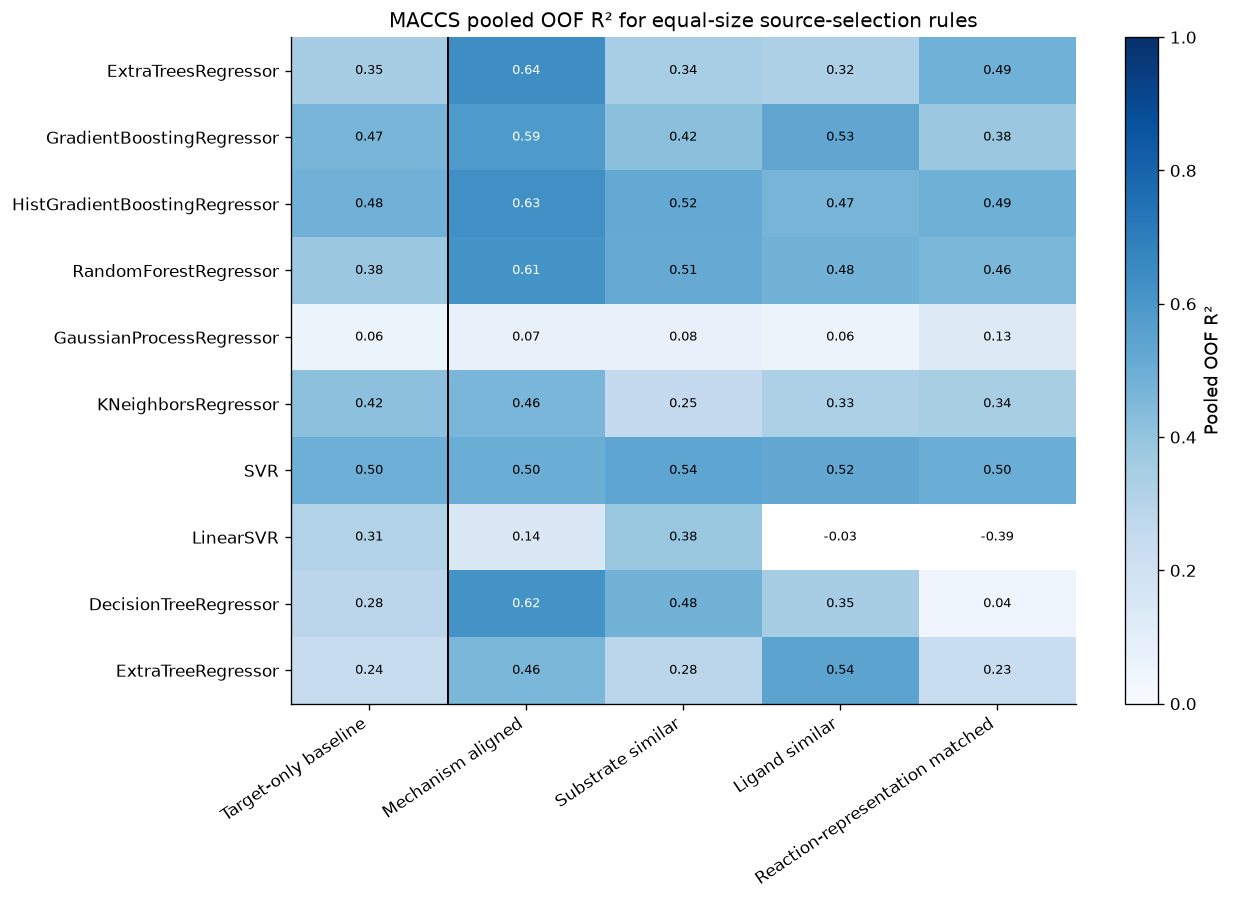

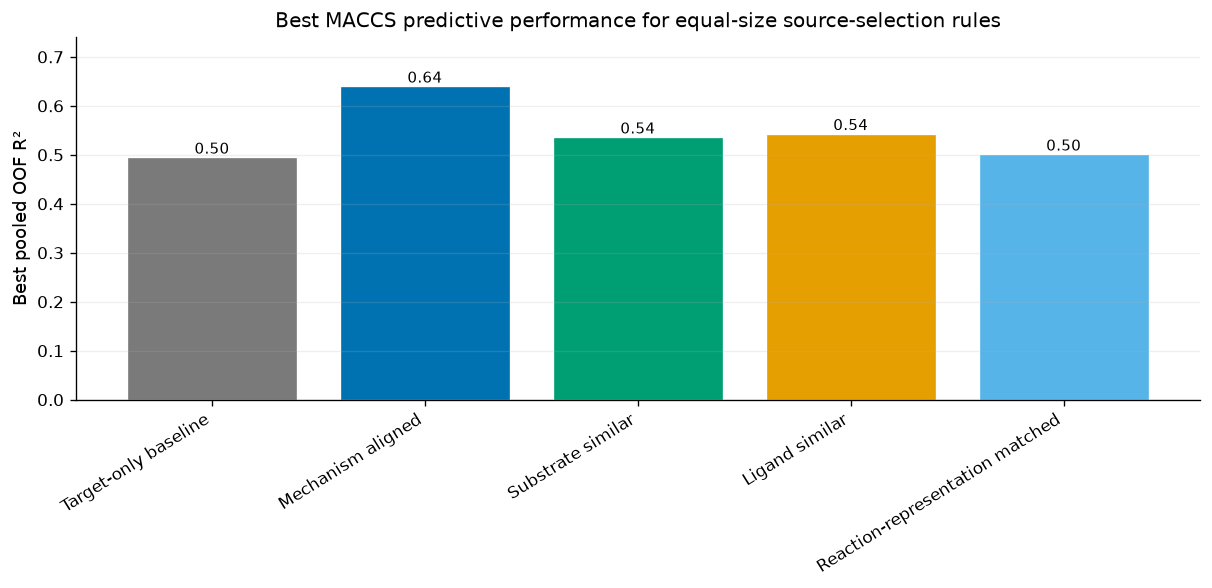

,source_rule_id,source_label,model,method_label,R2,MAE,RMSE
0,target_only,Target-only baseline,SVR,Target-only,0.495043,0.452117,0.672032
1,mechanism_aligned,Mechanism aligned,ExtraTreesRegressor,Mixed transfer,0.640186,0.350487,0.567286
2,substrate_similar,Substrate similar,SVR,Mixed transfer,0.536198,0.432942,0.644064
3,ligand_similar,Ligand similar,ExtraTreeRegressor,Delta learning,0.543234,0.401073,0.639160
4,reaction_representation_matched,Reaction-representation matched,SVR,Delta learning,0.501352,0.453373,0.667820


In [17]:
RULE_LABEL_MAP = {
    rule_id: rule["label"] for rule_id, rule in SOURCE_RULES.items()
}

# =========================
# 7.1 Absolute pooled OOF R² heatmap
# =========================
BASELINE_R2_SERIES = (
    BASELINE_METRICS.set_index("model")["baseline_R2"]
    .reindex(MODEL_KEYS_TO_RUN)
    .rename("Target-only baseline")
)

SELECTED_ABSOLUTE_R2 = (
    SELECTED_DF.pivot_table(
        index="model",
        columns="source_rule_id",
        values="R2",
        aggfunc="first",
        observed=True,
    )
    .reindex(index=MODEL_KEYS_TO_RUN)
    .reindex(columns=SOURCE_RULE_ORDER)
)
SELECTED_ABSOLUTE_R2.columns = [
    RULE_LABEL_MAP[str(column)]
    for column in SELECTED_ABSOLUTE_R2.columns
]

ABSOLUTE_R2_HEATMAP = pd.concat(
    [BASELINE_R2_SERIES, SELECTED_ABSOLUTE_R2],
    axis=1,
)
ABSOLUTE_R2_HEATMAP.to_csv(
    TABLE_DIR
    / "maccs_selected_transfer_absolute_R2_model_by_source_rule.csv"
)

absolute_values = ABSOLUTE_R2_HEATMAP.to_numpy(dtype=float)

# Fixed publication-comparable R² scale; values below 0 are white.
absolute_cmap = plt.get_cmap("Blues").copy()
absolute_cmap.set_under("#FFFFFF")
absolute_cmap.set_bad("#FFFFFF")

fig_w = max(
    10.8,
    0.95 * ABSOLUTE_R2_HEATMAP.shape[1] + 3.0,
)
fig_h = max(
    4.5,
    0.58 * ABSOLUTE_R2_HEATMAP.shape[0] + 1.8,
)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
image = ax.imshow(
    absolute_values,
    aspect="auto",
    cmap=absolute_cmap,
    vmin=0.0,
    vmax=1.0,
)
ax.set_xticks(
    np.arange(ABSOLUTE_R2_HEATMAP.shape[1])
)
ax.set_xticklabels(
    ABSOLUTE_R2_HEATMAP.columns,
    rotation=34,
    ha="right",
)
ax.set_yticks(
    np.arange(ABSOLUTE_R2_HEATMAP.shape[0])
)
ax.set_yticklabels(
    ABSOLUTE_R2_HEATMAP.index
)
ax.axvline(
    0.5,
    color="black",
    linewidth=1.2,
)
ax.set_title(
    "MACCS pooled OOF R² for equal-size source-selection rules"
)

for row_index in range(
    ABSOLUTE_R2_HEATMAP.shape[0]
):
    for column_index in range(
        ABSOLUTE_R2_HEATMAP.shape[1]
    ):
        value = ABSOLUTE_R2_HEATMAP.iloc[
            row_index,
            column_index,
        ]
        if pd.notna(value):
            ax.text(
                column_index,
                row_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=("white" if 0.55 <= float(value) <= 1.0 else "black"),
            )

colorbar = fig.colorbar(image, ax=ax, ticks=np.linspace(0.0, 1.0, 6))
colorbar.set_label("Pooled OOF R²")
fig.tight_layout()
fig.savefig(
    FIG_DIR
    / "maccs_selected_transfer_absolute_R2_source_rule_heatmap.svg",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

# =========================
# 7.2 Best absolute pooled OOF R² for each source rule
# =========================
best_baseline_row = (
    BASELINE_METRICS.sort_values(
        ["baseline_R2", "baseline_MAE", "baseline_RMSE"],
        ascending=[False, True, True],
    )
    .iloc[0]
)

baseline_best = pd.DataFrame(
    [
        {
            "source_rule_id": "target_only",
            "source_label": "Target-only baseline",
            "model": best_baseline_row["model"],
            "method_label": "Target-only",
            "R2": float(best_baseline_row["baseline_R2"]),
            "MAE": float(best_baseline_row["baseline_MAE"]),
            "RMSE": float(best_baseline_row["baseline_RMSE"]),
        }
    ]
)

transfer_best = BEST_SOURCE_DF[
    [
        "source_rule_id",
        "source_label",
        "model",
        "method_label",
        "R2",
        "MAE",
        "RMSE",
    ]
].copy()
transfer_best["source_rule_id"] = (
    transfer_best["source_rule_id"]
    .astype(str)
)

BEST_R2_BY_SOURCE_RULE_DF = pd.concat(
    [baseline_best, transfer_best],
    ignore_index=True,
)

best_rule_order = [
    "target_only",
    *SOURCE_RULE_ORDER,
]
BEST_R2_BY_SOURCE_RULE_DF[
    "source_rule_id"
] = pd.Categorical(
    BEST_R2_BY_SOURCE_RULE_DF["source_rule_id"],
    categories=best_rule_order,
    ordered=True,
)
BEST_R2_BY_SOURCE_RULE_DF = (
    BEST_R2_BY_SOURCE_RULE_DF.sort_values(
        "source_rule_id"
    )
    .reset_index(drop=True)
)
BEST_R2_BY_SOURCE_RULE_DF.to_csv(
    TABLE_DIR
    / "maccs_best_absolute_R2_by_source_rule.csv",
    index=False,
)

x = np.arange(
    len(BEST_R2_BY_SOURCE_RULE_DF)
)
values = BEST_R2_BY_SOURCE_RULE_DF[
    "R2"
].to_numpy(dtype=float)

fig, ax = plt.subplots(
    figsize=(
        max(
            10.2,
            1.05
            * len(BEST_R2_BY_SOURCE_RULE_DF),
        ),
        5.0,
    )
)
bar_colors = [
    SOURCE_RULE_COLORS[str(rule_id)]
    for rule_id in BEST_R2_BY_SOURCE_RULE_DF["source_rule_id"]
]
bars = ax.bar(
    x,
    values,
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
)

for bar, row in zip(
    bars,
    BEST_R2_BY_SOURCE_RULE_DF.itertuples(
        index=False
    ),
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row.R2:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    BEST_R2_BY_SOURCE_RULE_DF[
        "source_label"
    ],
    rotation=32,
    ha="right",
)
ax.set_ylabel("Best pooled OOF R²")
ax.set_title(
    "Best MACCS predictive performance for equal-size source-selection rules"
)
ax.set_ylim(
    min(0.0, float(np.nanmin(values)) - 0.05),
    float(np.nanmax(values)) + 0.10,
)
ax.grid(
    axis="y",
    alpha=0.2,
)
fig.tight_layout()
fig.savefig(
    FIG_DIR
    / "maccs_best_absolute_R2_by_source_rule.svg",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

display(BEST_R2_BY_SOURCE_RULE_DF)


## 8. Repeated equal-size mechanism-mismatched control

The complete mechanism-aligned source defines the common source size. To test
whether its performance can be reproduced simply by drawing the same amount
of data from the larger outer-sphere pool, we repeatedly sample equal-size
outer-sphere subsets using 20 predefined seeds (`42–61`).

Each sampled subset is shared across the five fixed target folds and is
evaluated with the same model pool and mixed/delta transfer choices used in the
primary analysis. Results are retained at two levels:

1. model-matched comparisons between the fixed mechanism-aligned source and
   every repeated mechanism-mismatched subset;
2. the distribution of the best pooled OOF R² obtained from the prespecified
   model pool in each repeat, matching the reporting convention used in the
   main figures.

The resulting distribution, summary statistics, and all repeat-level records
are exported so the data-size control does not depend on one arbitrary random
sample.


Equal-size mismatched repeat seed=37: n_source=495
Equal-size mismatched repeat seed=38: n_source=495
Equal-size mismatched repeat seed=39: n_source=495
Equal-size mismatched repeat seed=40: n_source=495
Equal-size mismatched repeat seed=41: n_source=495
Equal-size mismatched repeat seed=42: n_source=495
Equal-size mismatched repeat seed=43: n_source=495
Equal-size mismatched repeat seed=44: n_source=495
Equal-size mismatched repeat seed=45: n_source=495
Equal-size mismatched repeat seed=46: n_source=495


,representation,n_repeats,sample_seeds,source_size,aligned_best_model,aligned_best_method,aligned_best_R2,mismatched_best_R2_mean,mismatched_best_R2_std,mismatched_best_R2_median,mismatched_best_R2_q25,mismatched_best_R2_q75,mismatched_best_R2_min,mismatched_best_R2_max,aligned_minus_mismatched_mean_R2,n_repeats_aligned_higher,fraction_repeats_aligned_higher
0,MACCS,10,"37,38,39,40,41,42,43,44,45,46",495,ExtraTreesRegressor,Mixed transfer,0.640186,0.567355,0.015608,0.562005,0.55668,0.574258,0.55375,0.602581,0.072831,10,1.0


,model,aligned_R2,n_repeats,mismatched_R2_mean,mismatched_R2_std,mismatched_R2_median,mismatched_R2_min,mismatched_R2_max,aligned_advantage_mean,aligned_higher_fraction
0,ExtraTreesRegressor,0.640186,10,0.464317,0.065022,0.480246,0.368594,0.582190,0.175869,1.0
1,HistGradientBoostingRegressor,0.632018,10,0.500557,0.043109,0.518250,0.422160,0.548585,0.131461,1.0
2,DecisionTreeRegressor,0.619220,10,0.322035,0.122068,0.332331,0.181643,0.536611,0.297185,1.0
3,RandomForestRegressor,0.614792,10,0.511739,0.030021,0.514095,0.455869,0.554663,0.103052,1.0
4,GradientBoostingRegressor,0.589636,10,0.476297,0.070172,0.463574,0.373433,0.602581,0.113340,0.9
5,SVR,0.503852,10,0.558435,0.003924,0.557326,0.553750,0.564344,-0.054584,0.0
6,KNeighborsRegressor,0.461327,10,0.332082,0.051864,0.317275,0.271910,0.428024,0.129245,1.0
7,ExtraTreeRegressor,0.459463,10,0.371342,0.115860,0.333863,0.229136,0.577563,0.088120,0.7
8,LinearSVR,0.141443,10,-1.804794,1.593612,-1.450200,-5.287443,-0.095027,1.946236,1.0
9,GaussianProcessRegressor,0.074495,10,0.095251,0.006000,0.097344,0.085003,0.101754,-0.020756,0.0


,analysis_id,source_rule_id,source_label,source_partition,repeat_id,model,method_label,R2,MAE,RMSE,n_test_total,n_source_mean
0,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,37,SVR,Mixed transfer,0.564023,0.417664,0.624446,98,495.0
1,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,38,SVR,Mixed transfer,0.564344,0.419495,0.624216,98,495.0
2,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,39,ExtraTreesRegressor,Delta learning,0.582190,0.405824,0.611297,98,495.0
3,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,40,SVR,Mixed transfer,0.556198,0.427672,0.630025,98,495.0
4,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,41,GradientBoostingRegressor,Delta learning,0.602581,0.405224,0.596193,98,495.0
5,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,42,SVR,Mixed transfer,0.559988,0.422150,0.627329,98,495.0
6,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,43,SVR,Mixed transfer,0.558126,0.424707,0.628654,98,495.0
7,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,44,ExtraTreeRegressor,Mixed transfer,0.577563,0.392550,0.614673,98,495.0
8,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,45,SVR,Mixed transfer,0.553750,0.424389,0.631760,98,495.0
9,size_matched_mismatched_repeated,mechanism_mismatched_size_matched,"Mechanism mismatched, size matched",outer,46,SVR,Mixed transfer,0.554786,0.427412,0.631026,98,495.0


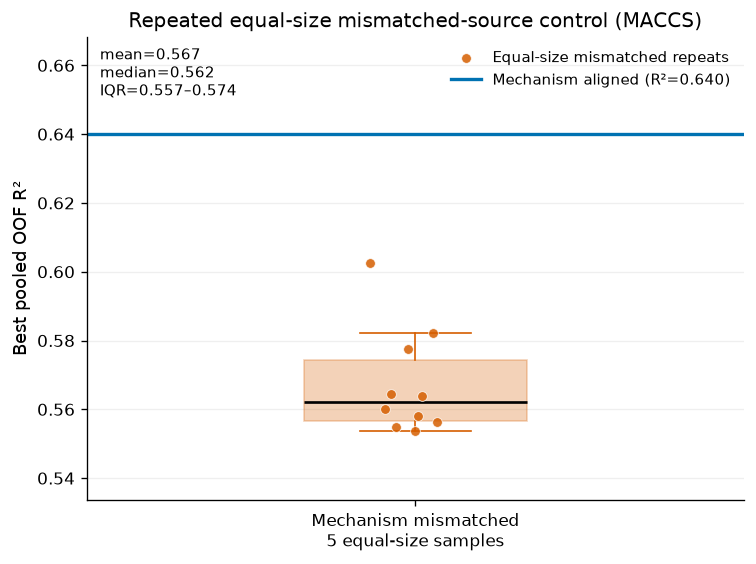

Best mechanism-aligned result: R²=0.640 (ExtraTreesRegressor, Mixed transfer)
Repeated equal-size mismatched best R²: mean=0.567, median=0.562, range=0.554–0.603
Aligned result higher in 10/10 repeated samples.


In [18]:
CUSTOM_OOF_COLUMNS = [
    "analysis_id",
    "source_rule_id",
    "source_label",
    "source_partition",
    "repeat_id",
    "model",
    "method_label",
    "fold_id",
    "target_index",
    "n_source",
    "y_true",
    "y_pred",
]


def run_custom_source_sets_oof(
    model_key,
    source_sets_by_fold,
    source_dataset_key,
    analysis_id,
    source_rule_id,
    source_label,
    source_partition,
    repeat_id=0,
):
    """Run mixed and delta transfer for arbitrary fold-specific source subsets."""
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    rows = []

    normalized_source_sets = {
        int(fold_id): np.asarray(indices, dtype=int)
        for fold_id, indices in source_sets_by_fold.items()
    }
    first_source = normalized_source_sets[1]
    shared_source_across_folds = all(
        np.array_equal(first_source, normalized_source_sets[int(fold_id)])
        for fold_id in range(1, len(TARGET_SPLITS) + 1)
    )

    shared_source_prior = None
    if shared_source_across_folds:
        if len(first_source) < 2:
            raise ValueError(
                f"{analysis_id}/{source_rule_id}/{source_partition}: "
                "shared source set has fewer than two reactions."
            )
        shared_source_prior = make_model(model_key)
        shared_source_prior.fit(
            FEATURES[source_dataset_key][first_source],
            TARGETS[source_dataset_key][first_source],
        )

    for fold_id, (train_idx, test_idx) in enumerate(TARGET_SPLITS, start=1):
        selected_indices = normalized_source_sets[int(fold_id)]
        if len(selected_indices) < 2:
            raise ValueError(
                f"{analysis_id}/{source_rule_id}/{source_partition}: "
                f"fold {fold_id} has fewer than two source reactions."
            )

        x_source = FEATURES[source_dataset_key][selected_indices]
        y_source = TARGETS[source_dataset_key][selected_indices]
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]

        if shared_source_prior is None:
            source_prior = make_model(model_key)
            source_prior.fit(x_source, y_source)
        else:
            source_prior = shared_source_prior

        mixed_model = make_model(model_key)
        mixed_model.fit(
            np.vstack([x_source, x_train]),
            np.concatenate([y_source, y_train]),
        )
        pred_mixed = predict_1d(mixed_model, x_test)

        delta_model = make_model(model_key)
        source_prior_train = predict_1d(source_prior, x_train)
        delta_model.fit(x_train, y_train - source_prior_train)
        pred_delta = (
            predict_1d(source_prior, x_test)
            + predict_1d(delta_model, x_test)
        )

        for method_label, pred in [
            ("Mixed transfer", pred_mixed),
            ("Delta learning", pred_delta),
        ]:
            for target_index, truth, pred_value in zip(test_idx, y_test, pred):
                rows.append(
                    {
                        "analysis_id": analysis_id,
                        "source_rule_id": source_rule_id,
                        "source_label": source_label,
                        "source_partition": source_partition,
                        "repeat_id": int(repeat_id),
                        "model": model_key,
                        "method_label": method_label,
                        "fold_id": int(fold_id),
                        "target_index": int(target_index),
                        "n_source": int(len(selected_indices)),
                        "y_true": float(truth),
                        "y_pred": float(pred_value),
                    }
                )
    return rows


def custom_pooled_metrics(oof_df):
    metric_rows = []
    group_columns = [
        "analysis_id",
        "source_rule_id",
        "source_label",
        "source_partition",
        "repeat_id",
        "model",
        "method_label",
    ]
    for keys, group in oof_df.groupby(group_columns, dropna=False):
        row = dict(zip(group_columns, keys))
        row.update(pooled_metrics(group["y_true"], group["y_pred"]))
        row["n_source_mean"] = float(group["n_source"].mean())
        metric_rows.append(row)
    return pd.DataFrame(metric_rows)


def select_better_custom_transfer_method(metric_df):
    """Select mix/delta by pooled OOF R², then MAE, RMSE, then mixed transfer."""
    candidates = metric_df.copy()
    candidates["_method_tie_break"] = (
        candidates["method_label"]
        .map({"Mixed transfer": 0, "Delta learning": 1})
        .fillna(99)
    )
    grouping = [
        "analysis_id",
        "source_rule_id",
        "source_partition",
        "repeat_id",
        "model",
    ]
    selected = (
        candidates.sort_values(
            grouping + ["R2", "MAE", "RMSE", "_method_tie_break"],
            ascending=[True] * len(grouping) + [False, True, True, True],
            na_position="last",
        )
        .groupby(grouping, as_index=False, sort=False)
        .head(1)
        .drop(columns="_method_tie_break")
        .reset_index(drop=True)
    )
    return selected


N_SIZE_MATCH_REPEATS = 5
SIZE_MATCH_SEEDS = list(
    range(RANDOM_STATE - N_SIZE_MATCH_REPEATS, RANDOM_STATE + N_SIZE_MATCH_REPEATS)
)

SIZE_MATCH_OOF_PATH = (
    TABLE_DIR / "maccs_compatible_size_matched_outer_repeat_oof.csv"
)
SIZE_MATCH_METRICS_PATH = (
    TABLE_DIR / "maccs_size_matched_outer_repeat_metrics.csv"
)
SIZE_MATCH_SELECTED_PATH = (
    TABLE_DIR / "maccs_size_matched_outer_repeat_best_method.csv"
)
SIZE_MATCH_COMPARISON_PATH = (
    TABLE_DIR / "maccs_size_matched_outer_repeat_model_comparison.csv"
)
SIZE_MATCH_MODEL_SUMMARY_PATH = (
    TABLE_DIR / "maccs_size_matched_outer_repeat_model_summary.csv"
)
SIZE_MATCH_BEST_REPEAT_PATH = (
    TABLE_DIR / "maccs_size_matched_outer_best_observed_by_repeat.csv"
)
SIZE_MATCH_SUMMARY_PATH = (
    TABLE_DIR / "maccs_size_matched_outer_repeat_summary.csv"
)


def repeated_oof_cache_is_compatible(path):
    if FORCE_RECOMPUTE_RESULTS or not path.exists():
        return False
    try:
        cached = pd.read_csv(path)
    except (EmptyDataError, OSError, ValueError):
        return False

    required_columns = set(CUSTOM_OOF_COLUMNS)
    if not required_columns.issubset(cached.columns):
        return False
    if set(cached["repeat_id"].astype(int).unique()) != set(SIZE_MATCH_SEEDS):
        return False
    if set(cached["model"].astype(str).unique()) != set(MODEL_KEYS_TO_RUN):
        return False
    if set(cached["method_label"].astype(str).unique()) != {
        "Mixed transfer",
        "Delta learning",
    }:
        return False
    if not cached["n_source"].astype(int).eq(N_ALIGNED).all():
        return False
    return True


# Remove outputs from the superseded fixed-seed and mechanism-split analyses.
for obsolete_path in TABLE_DIR.glob(
    "maccs_size_matched_outer_fixed_seed*.csv"
):
    obsolete_path.unlink()

for obsolete_name in [
    "maccs_similarity_selected_mechanism_composition_by_fold.csv",
    "maccs_similarity_selected_mechanism_composition_summary.csv",
    "maccs_similarity_selected_mechanism_split_oof.csv",
    "maccs_similarity_selected_mechanism_split_best_method.csv",
    "maccs_similarity_selected_mechanism_split_best_observed.csv",
    "maccs_similarity_selected_mechanism_split_balanced_repeat_oof.csv",
    "maccs_similarity_selected_mechanism_split_balanced_repeat_best_method.csv",
    "maccs_similarity_selected_mechanism_split_balanced_summary.csv",
    "maccs_similarity_selected_mechanism_split_balanced_best_observed.csv",
    "maccs_similarity_selected_mechanism_split_balance_audit.csv",
    "maccs_similarity_selected_mechanism_split_unbalanced_oof.csv",
    "maccs_similarity_selected_mechanism_split_unbalanced_best_method.csv",
]:
    obsolete_path = TABLE_DIR / obsolete_name
    if obsolete_path.exists():
        obsolete_path.unlink()

for obsolete_name in [
    "maccs_similarity_selected_mechanism_composition.svg",
    "maccs_similarity_selected_mechanism_split.svg",
    "maccs_similarity_selected_mechanism_split_balanced_delta_r2.svg",
    "maccs_similarity_selected_balanced_inner_vs_outer.svg",
    "maccs_size_matched_outer_repeat_R2.svg",
]:
    obsolete_path = FIG_DIR / obsolete_name
    if obsolete_path.exists():
        obsolete_path.unlink()


if repeated_oof_cache_is_compatible(SIZE_MATCH_OOF_PATH):
    SIZE_MATCH_OOF_DF = pd.read_csv(SIZE_MATCH_OOF_PATH)
    print("Loaded repeated size-matched control from", SIZE_MATCH_OOF_PATH)
else:
    size_match_rows = []
    for sample_seed in SIZE_MATCH_SEEDS:
        rng = np.random.default_rng(sample_seed)
        sampled_outer = np.sort(
            rng.choice(
                N_MISMATCHED,
                size=N_ALIGNED,
                replace=False,
            )
        )
        size_matched_source_sets = {
            int(fold_id): sampled_outer
            for fold_id in range(1, len(TARGET_SPLITS) + 1)
        }
        print(
            f"Equal-size mismatched repeat seed={sample_seed}: "
            f"n_source={len(sampled_outer)}"
        )

        for model_key in MODEL_KEYS_TO_RUN:
            size_match_rows.extend(
                run_custom_source_sets_oof(
                    model_key=model_key,
                    source_sets_by_fold=size_matched_source_sets,
                    source_dataset_key="ru_ahk_outer",
                    analysis_id="size_matched_mismatched_repeated",
                    source_rule_id="mechanism_mismatched_size_matched",
                    source_label="Mechanism mismatched, size matched",
                    source_partition="outer",
                    repeat_id=sample_seed,
                )
            )

    SIZE_MATCH_OOF_DF = pd.DataFrame(
        size_match_rows,
        columns=CUSTOM_OOF_COLUMNS,
    )
    SIZE_MATCH_OOF_DF.to_csv(SIZE_MATCH_OOF_PATH, index=False)

SIZE_MATCH_METRICS_DF = custom_pooled_metrics(SIZE_MATCH_OOF_DF)
SIZE_MATCH_SELECTED_DF = select_better_custom_transfer_method(
    SIZE_MATCH_METRICS_DF
)
SIZE_MATCH_METRICS_DF.to_csv(SIZE_MATCH_METRICS_PATH, index=False)
SIZE_MATCH_SELECTED_DF.to_csv(SIZE_MATCH_SELECTED_PATH, index=False)

aligned_by_model = (
    SELECTED_DF.loc[
        SELECTED_DF["source_rule_id"].astype(str).eq("mechanism_aligned"),
        ["model", "method_label", "R2", "MAE", "RMSE"],
    ]
    .rename(
        columns={
            "method_label": "aligned_method",
            "R2": "aligned_R2",
            "MAE": "aligned_MAE",
            "RMSE": "aligned_RMSE",
        }
    )
)

SIZE_MATCH_COMPARISON_DF = (
    SIZE_MATCH_SELECTED_DF[
        [
            "repeat_id",
            "model",
            "method_label",
            "R2",
            "MAE",
            "RMSE",
            "n_source_mean",
        ]
    ]
    .rename(
        columns={
            "method_label": "size_matched_outer_method",
            "R2": "size_matched_outer_R2",
            "MAE": "size_matched_outer_MAE",
            "RMSE": "size_matched_outer_RMSE",
        }
    )
    .merge(aligned_by_model, on="model", how="inner")
)
SIZE_MATCH_COMPARISON_DF[
    "delta_R2_aligned_minus_size_matched_outer"
] = (
    SIZE_MATCH_COMPARISON_DF["aligned_R2"]
    - SIZE_MATCH_COMPARISON_DF["size_matched_outer_R2"]
)
SIZE_MATCH_COMPARISON_DF.to_csv(
    SIZE_MATCH_COMPARISON_PATH,
    index=False,
)

SIZE_MATCH_MODEL_SUMMARY_DF = (
    SIZE_MATCH_COMPARISON_DF.groupby("model", as_index=False)
    .agg(
        aligned_R2=("aligned_R2", "first"),
        n_repeats=("repeat_id", "nunique"),
        mismatched_R2_mean=("size_matched_outer_R2", "mean"),
        mismatched_R2_std=("size_matched_outer_R2", "std"),
        mismatched_R2_median=("size_matched_outer_R2", "median"),
        mismatched_R2_min=("size_matched_outer_R2", "min"),
        mismatched_R2_max=("size_matched_outer_R2", "max"),
        aligned_advantage_mean=(
            "delta_R2_aligned_minus_size_matched_outer",
            "mean",
        ),
        aligned_higher_fraction=(
            "delta_R2_aligned_minus_size_matched_outer",
            lambda values: float(np.mean(np.asarray(values) > 0)),
        ),
    )
    .sort_values("aligned_R2", ascending=False)
    .reset_index(drop=True)
)
SIZE_MATCH_MODEL_SUMMARY_DF.to_csv(
    SIZE_MATCH_MODEL_SUMMARY_PATH,
    index=False,
)

# Select the best prespecified model after mix/delta has been selected within
# each model. This mirrors the primary reporting convention without collapsing
# the repeat-level distribution to one random sample.
SIZE_MATCH_BEST_BY_REPEAT_DF = (
    SIZE_MATCH_SELECTED_DF.sort_values(
        ["repeat_id", "R2", "MAE", "RMSE"],
        ascending=[True, False, True, True],
        na_position="last",
    )
    .groupby("repeat_id", as_index=False, sort=True)
    .head(1)
    .sort_values("repeat_id")
    .reset_index(drop=True)
)
SIZE_MATCH_BEST_BY_REPEAT_DF.to_csv(
    SIZE_MATCH_BEST_REPEAT_PATH,
    index=False,
)

best_aligned = (
    BEST_SOURCE_DF.loc[
        BEST_SOURCE_DF["source_rule_id"].astype(str).eq("mechanism_aligned")
    ]
    .sort_values(["R2", "MAE", "RMSE"], ascending=[False, True, True])
    .iloc[0]
)
best_aligned_R2 = float(best_aligned["R2"])
repeat_best_R2 = SIZE_MATCH_BEST_BY_REPEAT_DF["R2"].to_numpy(dtype=float)

SIZE_MATCH_SUMMARY_DF = pd.DataFrame(
    [
        {
            "representation": "MACCS",
            "n_repeats": int(len(repeat_best_R2)),
            "sample_seeds": ",".join(map(str, SIZE_MATCH_SEEDS)),
            "source_size": int(N_ALIGNED),
            "aligned_best_model": str(best_aligned["model"]),
            "aligned_best_method": str(best_aligned["method_label"]),
            "aligned_best_R2": best_aligned_R2,
            "mismatched_best_R2_mean": float(np.mean(repeat_best_R2)),
            "mismatched_best_R2_std": float(np.std(repeat_best_R2, ddof=1)),
            "mismatched_best_R2_median": float(np.median(repeat_best_R2)),
            "mismatched_best_R2_q25": float(np.quantile(repeat_best_R2, 0.25)),
            "mismatched_best_R2_q75": float(np.quantile(repeat_best_R2, 0.75)),
            "mismatched_best_R2_min": float(np.min(repeat_best_R2)),
            "mismatched_best_R2_max": float(np.max(repeat_best_R2)),
            "aligned_minus_mismatched_mean_R2": float(
                best_aligned_R2 - np.mean(repeat_best_R2)
            ),
            "n_repeats_aligned_higher": int(
                np.sum(best_aligned_R2 > repeat_best_R2)
            ),
            "fraction_repeats_aligned_higher": float(
                np.mean(best_aligned_R2 > repeat_best_R2)
            ),
        }
    ]
)
SIZE_MATCH_SUMMARY_DF.to_csv(SIZE_MATCH_SUMMARY_PATH, index=False)

display(SIZE_MATCH_SUMMARY_DF)
display(SIZE_MATCH_MODEL_SUMMARY_DF)
display(SIZE_MATCH_BEST_BY_REPEAT_DF)

fig, ax = plt.subplots(figsize=(6.4, 4.8))
box = ax.boxplot(
    [repeat_best_R2],
    positions=[0],
    widths=0.34,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.6},
    boxprops={"facecolor": "#D55E00", "alpha": 0.28, "edgecolor": "#D55E00"},
    whiskerprops={"color": "#D55E00"},
    capprops={"color": "#D55E00"},
)

jitter_rng = np.random.default_rng(RANDOM_STATE)
jitter = jitter_rng.normal(loc=0.0, scale=0.035, size=len(repeat_best_R2))
ax.scatter(
    jitter,
    repeat_best_R2,
    color="#D55E00",
    edgecolor="white",
    linewidth=0.5,
    s=34,
    alpha=0.85,
    zorder=3,
    label="Equal-size mismatched repeats",
)
ax.axhline(
    best_aligned_R2,
    color="#0072B2",
    linewidth=2.0,
    label=f"Mechanism aligned (R²={best_aligned_R2:.3f})",
)
ax.set_xticks([0])
ax.set_xticklabels(
    [f"Mechanism mismatched\n{N_SIZE_MATCH_REPEATS} equal-size samples"]
)
ax.set_ylabel("Best pooled OOF R²")
ax.set_title("Repeated equal-size mismatched-source control (MACCS)")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, loc="best")

summary_row = SIZE_MATCH_SUMMARY_DF.iloc[0]
ax.text(
    0.02,
    0.98,
    (
        f"mean={summary_row['mismatched_best_R2_mean']:.3f}\n"
        f"median={summary_row['mismatched_best_R2_median']:.3f}\n"
        f"IQR={summary_row['mismatched_best_R2_q25']:.3f}–"
        f"{summary_row['mismatched_best_R2_q75']:.3f}"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
)

all_values = np.concatenate([repeat_best_R2, [best_aligned_R2]])
value_span = max(float(np.ptp(all_values)), 0.10)
ax.set_ylim(
    float(np.min(all_values) - 0.20 * value_span),
    float(np.max(all_values) + 0.28 * value_span),
)
fig.tight_layout()
fig.savefig(
    FIG_DIR / "maccs_size_matched_outer_repeat_distribution.svg",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

print(
    f"Best mechanism-aligned result: R²={best_aligned_R2:.3f} "
    f"({best_aligned['model']}, {best_aligned['method_label']})"
)
print(
    "Repeated equal-size mismatched best R²: "
    f"mean={np.mean(repeat_best_R2):.3f}, "
    f"median={np.median(repeat_best_R2):.3f}, "
    f"range={np.min(repeat_best_R2):.3f}–{np.max(repeat_best_R2):.3f}"
)
print(
    "Aligned result higher in "
    f"{int(np.sum(best_aligned_R2 > repeat_best_R2))}/"
    f"{len(repeat_best_R2)} repeated samples."
)
